# PCLab#3 - Group 2 - Henricus Bracht Erdem Bayrakcioglu Leonard Fischbach

**Course:** 20598 - Finance with Big Data
**Lab:** PC Lab #3 - Creating a Factor from Text Data (Week 4)

We build a monthly stock factor from Stocktwits messages. The files overlap, and the `symbol` column is often the wrong ticker, so the stock comes from the cashtag in the text. There are no sentiment labels in the files. The main signal is abnormal attention, not sentiment. Expensive steps are cached under `cache/`.


### 0.1 Imports and setup


In [1]:
import gc
import hashlib
import html
import itertools
import json
import re
import time
import unicodedata
import warnings
from collections import Counter
from pathlib import Path

from io import StringIO
import urllib.request

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import seaborn as sns
import statsmodels.api as sm
import torch
import yfinance as yf
from scipy import stats

import nltk
nltk.download("wordnet", quiet=True)
nltk.download("stopwords", quiet=True)

PROJECT_DIR = Path.cwd()
DATA_DIRS = [PROJECT_DIR / "UnlabelledDataset_2", PROJECT_DIR / "Data from 2010"]
CACHE_DIR = PROJECT_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
(CACHE_DIR / "sentiment").mkdir(parents=True, exist_ok=True)
USE_CACHE = True

RANDOM_SEED = 42
MARKET_TZ = "America/New_York"
FORMATION_HOUR_ET = 16

# Attention: 30-day unique users versus the stock's own previous 360 days.
ATT_WINDOW_DAYS = 30
BASELINE_WINDOWS = 12
MIN_USERS_FORMATION = 5
MIN_BASELINE_ATTENTION = 2
MIN_USABLE_BASELINE_FRAC = 0.60
ATT_WINDOW_DAYS_WEEKLY = 7
BASELINE_WINDOWS_WEEKLY = 12
MIN_USERS_FORMATION_WEEKLY = 3
BLACKOUT_START = pd.Timestamp("2017-09-01")
BLACKOUT_END = pd.Timestamp("2017-12-31")
FORMATION_START = pd.Timestamp("2014-01-01")
FORMATION_END = pd.Timestamp("2020-06-30")
PRICE_START, PRICE_END = "2012-06-01", "2020-12-31"

N_PORTFOLIOS = 10
N_PORTFOLIOS_WEEKLY = 5
HAC_LAGS = (0, 3, 6, 12)
MIN_STOCKS_PER_DECILE_FLOOR = 10

MODEL_KEYS = ("roberta", "finbert", "vader")
MODEL_IDS = {
    "roberta": "cardiffnlp/twitter-roberta-base-sentiment-latest",
    "finbert": "ProsusAI/finbert",
    "vader": "vaderSentiment (lexicon, local)",
}
TRANSFORMER_KEYS = ("roberta", "finbert")
SENTIMENT_CAP_PER_CELL = 200
SENTIMENT_MAX_LEN = 64
SENTIMENT_BATCH_SIZE = 256
SENTIMENT_SHARD_ROWS = 100_000
BENCHMARK_CLASS_THRESHOLD = 0.25
N_BOOTSTRAP = 1_000
VOCAB_SAMPLE_N = 500_000
WORDCLOUD_SAMPLE_N = 150_000
DISAGREEMENT_MIN_USERS = 50

# Scraped StockTwits files: equities vs index/ETF/vol proxies in the same drop.
FOCAL_EQUITY_TICKERS = [
    "AAPL", "AMZN", "NFLX", "TSLA",
    "ADBE", "BAC", "BRK.A", "BRK.B", "DIS", "FB", "GOOG", "GOOGL", "HD",
    "INTC", "JNJ", "PG", "T", "UNH", "V", "VZ", "WMT",
]
FOCAL_NON_EQUITY_TICKERS = ("DIA", "QQQ", "SPY", "VIX")
FOCAL_TICKERS = list(FOCAL_EQUITY_TICKERS) + list(FOCAL_NON_EQUITY_TICKERS)
# Factor universe = FOCAL_EQUITY_TICKERS only; these four stay out of portfolios.
NON_EQUITY_TICKERS = set(FOCAL_NON_EQUITY_TICKERS)

if torch.backends.mps.is_available():
    TORCH_DEVICE = "mps"
elif torch.cuda.is_available():
    TORCH_DEVICE = "cuda"
else:
    TORCH_DEVICE = "cpu"

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 200, "savefig.bbox": "tight",
    "figure.figsize": (9.0, 5.0), "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 10.0, "axes.titlesize": 11.5, "axes.labelsize": 10.0,
    "xtick.labelsize": 9.0, "ytick.labelsize": 9.0, "legend.fontsize": 9.0,
    "legend.frameon": False, "axes.grid": True, "grid.alpha": 0.30, "grid.linewidth": 0.7,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#444444",
    "lines.linewidth": 1.8,
})
PALETTE = {
    "primary": "steelblue", "accent": "#c44e52", "neutral": "#8c8c8c",
    "positive": "#2a7f62", "negative": "#b03a2e", "highlight": "#d9822b",
    "shade": "#d9d9d9", "focal": "#8172b2",
}

def label_figure(fig, title, subtitle=None, source=None):
    top = 0.90 if subtitle else 0.94
    fig.tight_layout(rect=(0, 0.02, 1, top))
    fig.text(0.01, 0.985, title, fontsize=12.5, fontweight="bold",
             ha="left", va="top", color="#1a1a1a")
    if subtitle:
        fig.text(0.01, 0.935, subtitle, fontsize=9.2, ha="left", va="top",
                 color="#555555")
    if source:
        fig.text(0.01, 0.005, source, fontsize=7.6, ha="left", va="bottom",
                 color="#888888")
    return fig

def add_error_bars(ax, x, y, se, k=2.0, color=None, label=None, **kw):
    color = color or PALETTE["primary"]
    ax.errorbar(x, y, yerr=k * np.asarray(se), fmt="o", color=color, ecolor=color,
                elinewidth=1.3, capsize=3.5, markersize=6.5, alpha=0.95,
                label=label, **kw)
    return ax

def pct_axis(ax, axis="y", decimals=1):
    fmt = mticker.FuncFormatter(lambda v, _: f"{v * 100:.{decimals}f}%")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)
    return ax

print(f"torch {torch.__version__} on {TORCH_DEVICE}. Seed {RANDOM_SEED}.")
print("Cached intermediates in cache/ are reused. The raw CSVs are not modified.")


torch 2.14.0 on mps. Seed 42.
Cached intermediates in cache/ are reused. The raw CSVs are not modified.


---

## Task #1 — Data and descriptive statistics

### 1.1 Loading and cleaning

The data are 25 CSV files in two folders. The folders overlap, so we keep one row per `message_id`. The ticker is the cashtag in the message (`$AAPL`), not the `symbol` column, which is constant inside each file. The factor uses only the scraped focal equities (DIA/QQQ/SPY/VIX stay in descriptives, not in portfolios).


In [2]:
CSV_DTYPES = {"symbol": "string", "message": "string", "user": "int64", "message_id": "int64"}
files, file_folder = [], []
for folder in DATA_DIRS:
    if not folder.exists():
        raise FileNotFoundError(folder)
    paths = sorted(folder.glob("stocktwits_*.csv"))
    files.extend(paths)
    file_folder.extend([folder.name] * len(paths))
print(f"{len(files)} CSV files")

parts = []
for file_no, path in enumerate(files):
    raw = pd.read_csv(path, usecols=["symbol", "message_id"],
                      dtype={"symbol": "string", "message_id": "int64"})
    parts.append(pd.DataFrame({
        "file_no": np.full(len(raw), file_no, dtype=np.int16),
        "pos": np.arange(len(raw), dtype=np.int64),
        "message_id": raw["message_id"].to_numpy(),
        "n_symbols": raw["symbol"].nunique(),
    }))
message_index = pd.concat(parts, ignore_index=True)
message_index["folder"] = message_index["file_no"].map(dict(enumerate(file_folder)))

n_rows = len(message_index)
n_ids = message_index["message_id"].nunique()
in_several_files = int((message_index.groupby("message_id")["file_no"].nunique() > 1).sum())
in_both_folders = int((message_index.groupby("message_id")["folder"].nunique() > 1).sum())
within_file = int(message_index.duplicated(["file_no", "message_id"]).sum())
print(f"Rows across all files              : {n_rows:,}")
print(f"Distinct message_id                : {n_ids:,}")
print(f"Rows removed by dropping duplicates: {n_rows - n_ids:,} "
      f"({(n_rows - n_ids) / n_rows:.1%})")
print(f"message_ids in more than one file  : {in_several_files:,}")
print(f"message_ids in both folders        : {in_both_folders:,}")
print(f"Repeated (file, message_id) rows   : {within_file:,}")


def parse_market_time(raw):
    utc = pd.to_datetime(raw, format="ISO8601", utc=True)
    return utc, utc.dt.tz_convert(MARKET_TZ)


messages_path = CACHE_DIR / "messages.parquet"
if messages_path.exists():
    print(f"Using cached messages ({messages_path.stat().st_size / 1e6:,.0f} MB)")
else:
    keep = message_index.drop_duplicates("message_id", keep="first")
    keep_by_file = {int(f): np.sort(g["pos"].to_numpy()) for f, g in keep.groupby("file_no")}
    schema = pa.schema([
        ("message_id", pa.int64()), ("message", pa.large_string()),
        ("dt_utc", pa.timestamp("ns", tz="UTC")),
        ("dt_et", pa.timestamp("ns", tz=MARKET_TZ)),
        ("user", pa.int64()), ("src_file", pa.string()), ("provided_symbol", pa.string()),
    ])
    tmp = messages_path.with_suffix(".building.parquet")
    with pq.ParquetWriter(tmp, schema, compression="zstd") as writer:
        for file_no, src in enumerate(files):
            df = pd.read_csv(src, dtype=CSV_DTYPES, keep_default_na=False, na_values=[""])
            df = df.iloc[keep_by_file.get(file_no, np.array([], dtype=np.int64))]
            utc, et = parse_market_time(df["datetime"])
            out = pd.DataFrame({
                "message_id": df["message_id"].to_numpy(),
                "message": df["message"].fillna("").astype(object),
                "dt_utc": utc.to_numpy(), "dt_et": et.to_numpy(),
                "user": df["user"].to_numpy(), "src_file": src.name,
                "provided_symbol": df["symbol"].fillna("").astype(object),
            })
            writer.write_table(pa.Table.from_pandas(out, schema=schema, preserve_index=False))
    tmp.replace(messages_path)

del message_index
gc.collect()
messages_meta = pd.read_parquet(
    messages_path, columns=["message_id", "dt_utc", "dt_et", "user", "src_file", "provided_symbol"])
assert messages_meta["message_id"].is_unique
assert messages_meta[["message_id", "user", "dt_utc", "dt_et"]].notna().all().all()
print(f"Canonical corpus: {len(messages_meta):,} messages, "
      f"{messages_meta['user'].nunique():,} accounts, "
      f"{messages_meta['dt_et'].min().date()} to {messages_meta['dt_et'].max().date()}")


25 CSV files
Rows across all files              : 6,483,233
Distinct message_id                : 5,564,920
Rows removed by dropping duplicates: 918,313 (14.2%)
message_ids in more than one file  : 666,279
message_ids in both folders        : 242,507
Repeated (file, message_id) rows   : 73,148
Using cached messages (345 MB)
Canonical corpus: 5,564,920 messages, 135,835 accounts, 2009-07-10 to 2020-07-23


About one row in seven is a duplicate, mostly because the same message was saved in both folders. Two different people posting the same sentence are both kept.


In [3]:
# A cashtag is $ plus 1-6 letters, optionally a dotted share class.
# $AAPL250 is not a ticker, and $1.5B is not one either.
CASHTAG_RE = re.compile(r"(?<![A-Za-z0-9.$])\$([A-Za-z]{1,6}(?:[.\-][A-Za-z]{1,2})?)(?![A-Za-z0-9])")
SHARE_CLASS_SPELLINGS = {"BRKA": "BRK.A", "BRKB": "BRK.B", "BFA": "BF.A", "BFB": "BF.B"}
TICKER_RENAMES = {
    "FB": "META", "PCLN": "BKNG", "ANTM": "ELV", "FISV": "FI", "WLTW": "WTW",
    "TMK": "GL", "BBT": "TFC", "DPS": "KDP", "LUK": "JEF", "RE": "EG", "SQ": "XYZ",
}

def normalise_ticker(tag):
    t = tag.upper().replace("-", ".")
    return SHARE_CLASS_SPELLINGS.get(t, t)

def extract_cashtags(text):
    if not text:
        return []
    seen, out = set(), []
    for tag in CASHTAG_RE.findall(text):
        t = normalise_ticker(tag)
        if t not in seen:
            seen.add(t)
            out.append(t)
    return out

def build_mentions(message_ids, texts):
    tags = [CASHTAG_RE.findall(t) if t else [] for t in texts]
    counts = np.fromiter((len(t) for t in tags), dtype=np.int64, count=len(tags))
    flat = list(itertools.chain.from_iterable(tags))
    tickers = [SHARE_CLASS_SPELLINGS.get(t, t) for t in
               (s.upper().replace("-", ".") for s in flat)]
    out = pd.DataFrame({
        "message_id": np.repeat(np.asarray(message_ids, dtype=np.int64), counts),
        "ticker": pd.Series(tickers, dtype="string"),
    })
    return out.drop_duplicates(["message_id", "ticker"], ignore_index=True)

def resolve_to_universe(tickers):
    s = pd.Series(tickers, dtype="string").str.upper()
    return s.replace(ACTIVE_RENAMES)


In [4]:
# Factor universe = scraped focal equities only (no S&P co-mention panel).
# Historical cashtags (e.g. FB) map to the current Yahoo symbol when known.
_focal_equity_raw = [normalise_ticker(t) for t in FOCAL_EQUITY_TICKERS]
ACTIVE_RENAMES = {
    old: new for old, new in TICKER_RENAMES.items()
    if old in _focal_equity_raw or new in _focal_equity_raw
}
security_universe = sorted({ACTIVE_RENAMES.get(t, t) for t in _focal_equity_raw})
UNIVERSE_SET = set(security_universe)

FOCAL_NORMALISED = sorted({
    ACTIVE_RENAMES.get(normalise_ticker(t), normalise_ticker(t)) for t in FOCAL_TICKERS
})
FOCAL_NON_EQUITY = sorted({
    ACTIVE_RENAMES.get(normalise_ticker(t), normalise_ticker(t))
    for t in FOCAL_NON_EQUITY_TICKERS
})
print(f"Factor universe (focal equities): {len(security_universe)}")
print("  " + ", ".join(security_universe))
print("Focal non-equities (descriptives only):", ", ".join(FOCAL_NON_EQUITY))
print("Active renames:",
      ", ".join(f"{a}->{b}" for a, b in sorted(ACTIVE_RENAMES.items())) or "none")


Factor universe (focal equities): 21
  AAPL, ADBE, AMZN, BAC, BRK.A, BRK.B, DIS, GOOG, GOOGL, HD, INTC, JNJ, META, NFLX, PG, T, TSLA, UNH, V, VZ, WMT
Focal non-equities (descriptives only): DIA, QQQ, SPY, VIX
Active renames: FB->META


In [5]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
EMOJI_RE = re.compile(
    "[" "\U0001F300-\U0001F9FF" "\U0001F000-\U0001F02F" "\U00002600-\U000027BF"
    "\U0001F1E6-\U0001F1FF" "\U00002190-\U00002BFF" "\U0000FE00-\U0000FE0F" "]"
)

def daily_attention_panel(mentions):
    base = mentions[["date", "ticker", "user", "message_id"]]
    users = (base.drop_duplicates(["date", "ticker", "user"])
                 .groupby(["date", "ticker"], observed=True).size().rename("U"))
    msgs = base.groupby(["date", "ticker"], observed=True).size().rename("N")
    return pd.concat([users, msgs], axis=1).reset_index()

def build_mentions_and_message_stats(batch_size=400_000):
    pf = pq.ParquetFile((CACHE_DIR / "messages.parquet"))
    mention_parts, stat_parts = [], []
    for batch in pf.iter_batches(batch_size=batch_size,
                                 columns=["message_id", "message"]):
        mid = batch.column("message_id").to_numpy()
        txt = batch.column("message").to_pylist()
        mention_parts.append(build_mentions(mid, txt))
        stat_parts.append(pd.DataFrame({
            "message_id": mid,
            "n_chars": np.fromiter((len(t) for t in txt), np.int32, len(txt)),
            "n_words": np.fromiter((len(t.split()) for t in txt), np.int32, len(txt)),
            "n_cashtags": np.fromiter((len(CASHTAG_RE.findall(t)) for t in txt),
                                      np.int16, len(txt)),
            "has_url": np.fromiter((URL_RE.search(t) is not None for t in txt),
                                   bool, len(txt)),
            "has_emoji": np.fromiter((EMOJI_RE.search(t) is not None for t in txt),
                                     bool, len(txt)),
            "has_html_entity": np.fromiter(("&" in t and html.unescape(t) != t
                                            for t in txt), bool, len(txt)),
        }))
        del txt, mid
    mentions_raw = pd.concat(mention_parts, ignore_index=True)
    stats = pd.concat(stat_parts, ignore_index=True)
    del mention_parts, stat_parts
    gc.collect()
    return mentions_raw, stats


# Daily panel = all scraped focals (equities + DIA/QQQ/SPY/VIX). Factor later drops non-equities.
PANEL_TICKERS = set(FOCAL_NORMALISED)

# Cache only the expensive mention extract (from messages.parquet). Daily panel is cheap.
mentions_path = CACHE_DIR / "mentions.parquet"
stats_path = CACHE_DIR / "message_stats.parquet"
if mentions_path.exists() and stats_path.exists():
    mentions = pd.read_parquet(mentions_path)
    message_stats = pd.read_parquet(stats_path)
else:
    core, message_stats = build_mentions_and_message_stats()
    message_stats.to_parquet(stats_path, index=False)
    core = core.merge(messages_meta[["message_id", "dt_et", "user"]], on="message_id", how="left")
    core["date"] = core["dt_et"].dt.tz_localize(None).dt.normalize()
    mentions = core[["message_id", "ticker", "dt_et", "user"]].copy()
    mentions.to_parquet(mentions_path, index=False)
    del core
    gc.collect()

mentions["ticker"] = mentions["ticker"].astype("category")
# Rebuild daily attention in memory (no parquet)
_mentions_for_panel = mentions.copy()
_mentions_for_panel["date"] = _mentions_for_panel["dt_et"].dt.tz_localize(None).dt.normalize()
attention_daily = daily_attention_panel(
    _mentions_for_panel.loc[
        _mentions_for_panel["ticker"].isin(PANEL_TICKERS),
        ["date", "ticker", "user", "message_id"],
    ]
)
attention_daily["ticker"] = attention_daily["ticker"].astype("category")
del _mentions_for_panel

per_msg = mentions.groupby("message_id", observed=True).size()
print(f"Cashtag mentions          : {len(mentions):,}")
print(f"Distinct cashtag strings  : {mentions['ticker'].nunique():,}")
print(f"Messages with no cashtag  : {len(messages_meta) - len(per_msg):,}")
print(f"Share with more than one  : {(per_msg > 1).mean():.1%}")
print(mentions["ticker"].value_counts().head(10).to_string())

panel_check = mentions.loc[mentions["ticker"].isin(PANEL_TICKERS)]
assert int(attention_daily["N"].sum()) == len(panel_check)
print("Daily user/message panel matches the mention table.")


Cashtag mentions          : 9,727,661
Distinct cashtag strings  : 18,198
Messages with no cashtag  : 2,774
Share with more than one  : 27.6%
ticker
TSLA    1799927
AAPL    1289571
SPY      678904
NFLX     669568
QQQ      594322
AMZN     564784
DIS      241102
DIA      190431
VIX      174584
FB       172437
Daily user/message panel matches the mention table.


More than a quarter of messages name more than one ticker. Mentions of names outside the 25 files are ignored for the factor; we only keep the focal equities.


In [6]:
CONTAMINATION_THRESHOLD = 0.40

def _folder_for(src_file):
    for folder in DATA_DIRS:
        if (folder / src_file).exists():
            return folder.name
    return "?"

def build_symbol_contamination():
    """Per source file: share of deduped messages lacking the file's own cashtag.

    Uses messages_meta + mentions (from messages.parquet) — no CSV re-read.
    """
    meta = messages_meta[["message_id", "src_file", "provided_symbol"]].copy()
    ment = mentions[["message_id", "ticker"]].copy()
    ment["ticker"] = ment["ticker"].astype(str)

    file_own = (
        meta.groupby("src_file", observed=True)["provided_symbol"]
        .agg(lambda s: normalise_ticker(str(s.mode().iloc[0])))
    )
    meta["own_ticker"] = meta["src_file"].map(file_own)

    tagged = ment.merge(meta[["message_id", "own_ticker"]], on="message_id", how="inner")
    has_own_ids = set(tagged.loc[tagged["ticker"] == tagged["own_ticker"], "message_id"])

    rows = []
    for src_file, g in meta.groupby("src_file", observed=True, sort=True):
        own = g["own_ticker"].iloc[0]
        ids = g["message_id"]
        n = len(g)
        with_own = int(ids.isin(has_own_ids).sum())
        miss_ids = ids[~ids.isin(has_own_ids)]
        other = ment.loc[
            ment["message_id"].isin(miss_ids) & (ment["ticker"] != own), "ticker"]
        intruders = Counter(other.tolist())
        modal, modal_n = intruders.most_common(1)[0] if intruders else ("-", 0)
        rows.append({
            "file": src_file,
            "folder": _folder_for(src_file),
            "file_ticker": src_file.replace("stocktwits_", "").replace(".csv", ""),
            "own_ticker": own,
            "rows": n,
            "with_own_ticker": with_own,
            "modal_intruder": modal,
            "modal_intruder_rows": int(modal_n),
        })
    out = pd.DataFrame(rows)
    out["share_missing_own"] = 1 - out["with_own_ticker"] / out["rows"]
    out["intruder_share"] = out["modal_intruder_rows"] / out["rows"]
    return out.sort_values("share_missing_own", ascending=False, ignore_index=True)

contamination = build_symbol_contamination()

n_blended = int((contamination["share_missing_own"] > CONTAMINATION_THRESHOLD).sum())
print(contamination[["file_ticker", "folder", "rows", "share_missing_own",
                     "modal_intruder", "intruder_share"]].to_string(index=False))
print(f"\n{n_blended} of {len(contamination)} files are blends "
      f"(more than {CONTAMINATION_THRESHOLD:.0%} of deduped messages lack the file's own cashtag).")


file_ticker              folder    rows  share_missing_own modal_intruder  intruder_share
      GOOGL      Data from 2010  108029           0.729276           GOOG        0.728230
        JNJ      Data from 2010   39036           0.679834              T        0.677426
      BRK.B      Data from 2010   33718           0.628151            BAC        0.627795
        UNH      Data from 2010   16136           0.600830              V        0.600397
        BAC      Data from 2010  165879           0.519041           AMZN        0.518275
         FB      Data from 2010  112115           0.504161            DIS        0.500789
        WMT      Data from 2010   13677           0.492871             VZ        0.491116
       INTC      Data from 2010   15502           0.492711             HD        0.491356
        SPY      Data from 2010  153794           0.441610            VIX        0.440167
        QQQ UnlabelledDataset_2  595671           0.002527            SPY        0.001949
          

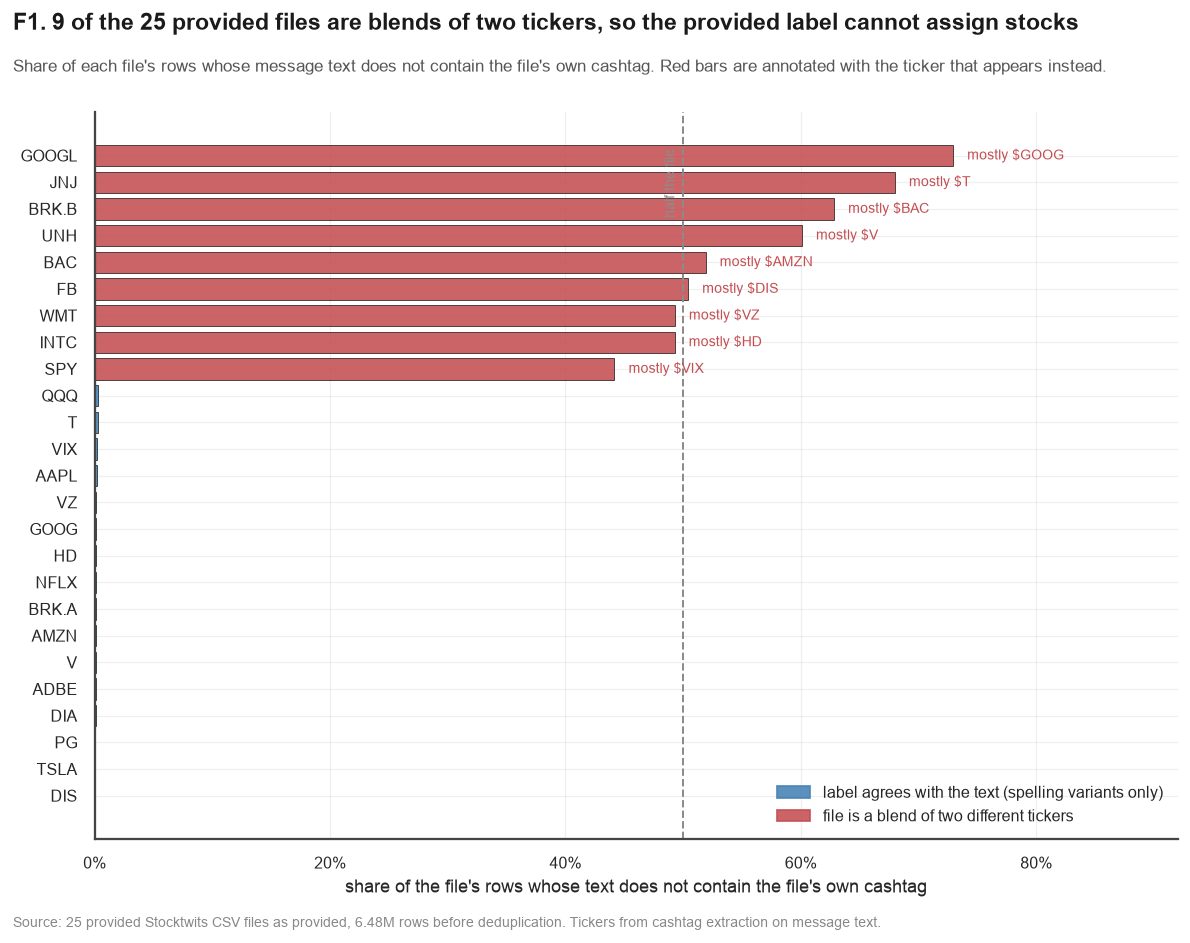

In [7]:
_c = contamination.sort_values("share_missing_own")
_colors = np.where(_c["share_missing_own"] > CONTAMINATION_THRESHOLD,
                   PALETTE["accent"], PALETTE["primary"])

fig, ax = plt.subplots(figsize=(9.2, 7.2))
ax.barh(_c["file_ticker"], _c["share_missing_own"], color=_colors,
        edgecolor="black", linewidth=0.4, alpha=0.88)
ax.axvline(0.50, color=PALETTE["neutral"], linestyle="--", linewidth=1.1)
ax.text(0.495, len(_c) - 0.6, "half the file ", fontsize=8, color=PALETTE["neutral"],
        rotation=90, va="top", ha="right")
for y, (_, row) in enumerate(_c.iterrows()):
    if row["share_missing_own"] > CONTAMINATION_THRESHOLD:
        ax.text(row["share_missing_own"] + 0.012, y,
                f"mostly ${row['modal_intruder']}", va="center", fontsize=8,
                color=PALETTE["accent"])
ax.set_xlim(0, 0.92)
ax.set_xlabel("share of deduped messages (by src_file) without the file's own cashtag")
ax.set_ylabel("")
pct_axis(ax, axis="x", decimals=0)
ax.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color=PALETTE["primary"], alpha=0.88,
                  label="label agrees with the text (spelling variants only)"),
    plt.Rectangle((0, 0), 1, 1, color=PALETTE["accent"], alpha=0.88,
                  label="file is a blend of two different tickers"),
], loc="lower right")
label_figure(
    fig,
    f"F1. {n_blended} of the 25 provided files are blends of two tickers, so the provided "
    f"label cannot assign stocks",
    "Share of deduplicated messages per src_file without the file's own cashtag. "
    "Red bars are annotated with the ticker that appears instead.",
    "Source: deduplicated messages.parquet attributed by src_file; cashtags from mentions.",
)
plt.show()


Nine of the 25 files are blends. The file labelled GOOGL is mostly GOOG, JNJ is mostly T, and SPY is mostly VIX. The other files miss their own ticker on about one row in a hundred. From here on, every stock is taken from the cashtag. Using `symbol` would have given a large block of attention to the wrong name.


### 1.2 Sample description


In [8]:
_msg = messages_meta.merge(message_stats, on="message_id", how="left")
_wq = _msg["n_words"].quantile([0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99])

print("The sample")
print("-" * 62)
print(f"  Messages (deduplicated)        : {len(_msg):,}")
print(f"  Distinct posting accounts      : {_msg['user'].nunique():,}")
print(f"  Cashtag mentions               : {len(mentions):,}")
print(f"  Distinct cashtag strings       : {mentions['ticker'].nunique():,}")
print(f"  First message (ET)             : {_msg['dt_et'].min()}")
print(f"  Last message (ET)              : {_msg['dt_et'].max()}")
print()
print("Words per message")
print("-" * 62)
print(f"  Mean                           : {_msg['n_words'].mean():.2f}")
print(f"  Median                         : {_msg['n_words'].median():.0f}")
print(f"  Standard deviation             : {_msg['n_words'].std():.2f}")
for q, v in _wq.items():
    print(f"  p{int(q * 100):<28}: {v:.0f}")
print()
print("Characters per message")
print("-" * 62)
print(f"  Mean / median                  : {_msg['n_chars'].mean():.1f} / "
      f"{_msg['n_chars'].median():.0f}")
print(f"  Share over 140 characters      : {100 * (_msg['n_chars'] > 140).mean():.1f}%")
print()
print("Message furniture that the cleaning pipeline in Task #2 has to handle")
print("-" * 62)
print(f"  Contain a URL                  : {100 * _msg['has_url'].mean():.1f}%")
print(f"  Contain an HTML entity         : {100 * _msg['has_html_entity'].mean():.1f}%")
print(f"  Contain an emoji               : {100 * _msg['has_emoji'].mean():.1f}%")
print(f"  Contain no cashtag at all      : {100 * (_msg['n_cashtags'] == 0).mean():.1f}%")


The sample
--------------------------------------------------------------
  Messages (deduplicated)        : 5,564,920
  Distinct posting accounts      : 135,835
  Cashtag mentions               : 9,727,661
  Distinct cashtag strings       : 18,198
  First message (ET)             : 2009-07-10 17:47:36-04:00
  Last message (ET)              : 2020-07-23 21:15:39-04:00

Words per message
--------------------------------------------------------------
  Mean                           : 15.26
  Median                         : 13
  Standard deviation             : 12.58
  p1                           : 1
  p10                          : 4
  p25                          : 8
  p50                          : 13
  p75                          : 20
  p90                          : 26
  p99                          : 64

Characters per message
--------------------------------------------------------------
  Mean / median                  : 94.0 / 82
  Share over 140 characters      : 13.6%

Mess

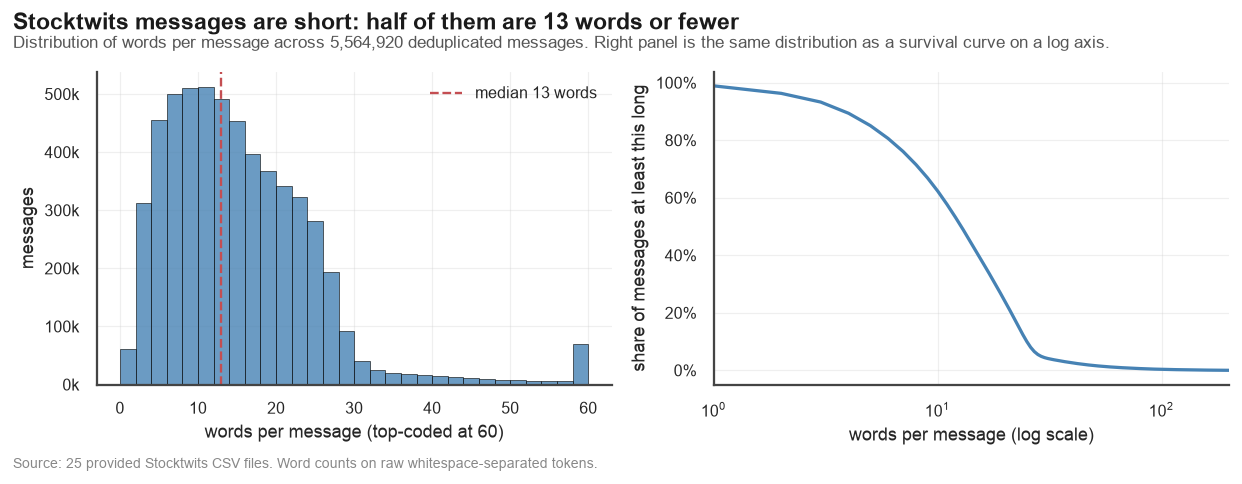

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.6))
_w = _msg["n_words"].clip(upper=60)
axes[0].hist(_w, bins=np.arange(0, 62, 2), color=PALETTE["primary"],
             edgecolor="black", linewidth=0.4, alpha=0.8)
axes[0].axvline(_msg["n_words"].median(), color=PALETTE["accent"], linestyle="--",
                linewidth=1.3,
                label=f"median {_msg['n_words'].median():.0f} words")
axes[0].set_xlabel("words per message (top-coded at 60)")
axes[0].set_ylabel("messages")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v / 1e3:,.0f}k"))
axes[0].legend()

_surv = (_msg["n_words"].value_counts(normalize=True).sort_index().cumsum())
axes[1].plot(_surv.index, 1 - _surv.values, color=PALETTE["primary"])
axes[1].set_xscale("log")
axes[1].set_xlim(1, 200)
axes[1].set_xlabel("words per message (log scale)")
axes[1].set_ylabel("share of messages at least this long")
pct_axis(axes[1], decimals=0)

label_figure(
    fig,
    "Stocktwits messages are short: half of them are 13 words or fewer",
    f"Distribution of words per message across {len(_msg):,} deduplicated messages. "
    f"Right panel is the same distribution as a survival curve on a log axis.",
    "Source: 25 provided Stocktwits CSV files. Word counts on raw whitespace-separated tokens.",
)
plt.show()


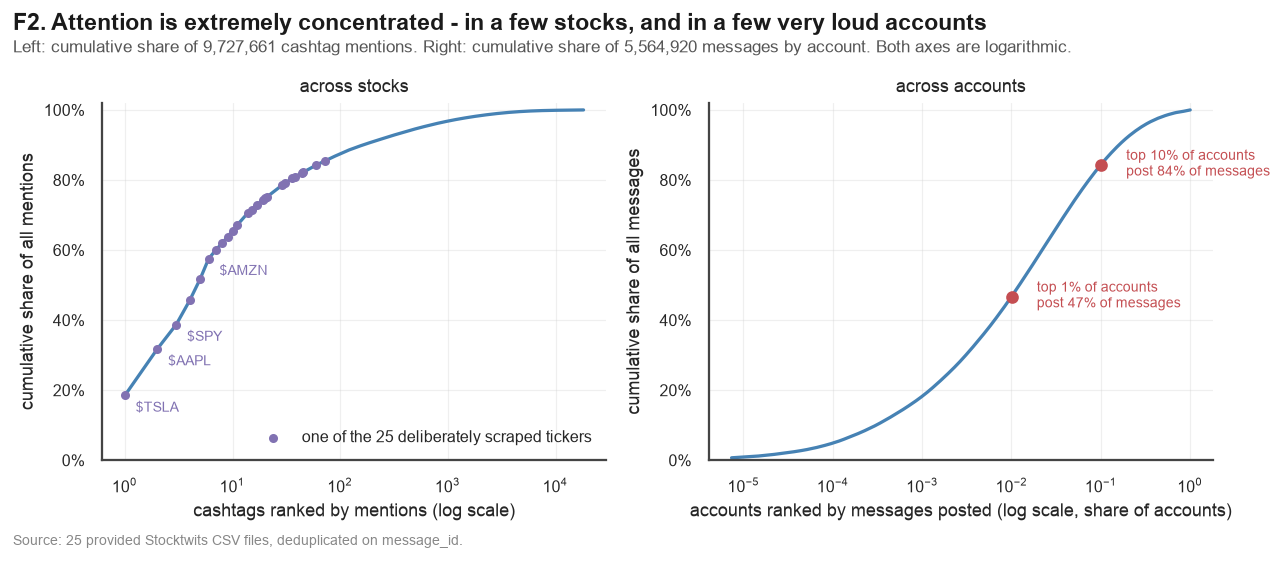

Top 10 cashtags take 65.5% of all mentions
Top 25 cashtags take 77.0% of all mentions
Top 1% of accounts post 46.7% of all messages

Highest-volume accounts:
user
47688     38975
316034    28142
349810    26098
64624     23256
296805    18637
596943    17950
800154    17197
260062    16816


In [10]:
_tick_counts = mentions["ticker"].value_counts()
_tick_share = _tick_counts / _tick_counts.sum()
_tick_cum = _tick_share.cumsum()
_focal_set = set(FOCAL_TICKERS)
_is_focal = np.array([t in _focal_set for t in _tick_counts.index])

_user_counts = messages_meta["user"].value_counts()
_user_cum = (_user_counts / _user_counts.sum()).cumsum()
_user_pct = np.arange(1, len(_user_counts) + 1) / len(_user_counts)

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2))

ax = axes[0]
ax.plot(np.arange(1, len(_tick_cum) + 1), _tick_cum.values, color=PALETTE["primary"])
_focal_rank = np.flatnonzero(_is_focal)
ax.scatter(_focal_rank + 1, _tick_cum.values[_focal_rank], s=16,
           color=PALETTE["focal"], zorder=3,
           label="one of the 25 deliberately scraped tickers")
for name in ["AAPL", "TSLA", "SPY", "AMZN"]:
    if name in _tick_cum.index:
        r = _tick_cum.index.get_loc(name) + 1
        ax.annotate(f"${name}", (r, _tick_cum.iloc[r - 1]), fontsize=8,
                    xytext=(6, -9), textcoords="offset points", color=PALETTE["focal"])
ax.set_xscale("log")
ax.set_xlabel("cashtags ranked by mentions (log scale)")
ax.set_ylabel("cumulative share of all mentions")
ax.set_ylim(0, 1.02)
pct_axis(ax, decimals=0)
ax.legend(loc="lower right")
ax.set_title("across stocks", fontsize=10)

ax = axes[1]
ax.plot(_user_pct, _user_cum.values, color=PALETTE["primary"])
for p in (0.01, 0.10):
    idx = int(np.ceil(p * len(_user_counts))) - 1
    ax.scatter([_user_pct[idx]], [_user_cum.values[idx]], color=PALETTE["accent"], zorder=3)
    ax.annotate(f"top {p:.0%} of accounts\npost {_user_cum.values[idx]:.0%} of messages",
                (_user_pct[idx], _user_cum.values[idx]), fontsize=8,
                xytext=(14, -6), textcoords="offset points", color=PALETTE["accent"])
ax.set_xscale("log")
ax.set_xlabel("accounts ranked by messages posted (log scale, share of accounts)")
ax.set_ylabel("cumulative share of all messages")
ax.set_ylim(0, 1.02)
pct_axis(ax, decimals=0)
ax.set_title("across accounts", fontsize=10)

label_figure(
    fig,
    "F2. Attention is extremely concentrated - in a few stocks, and in a few very loud accounts",
    f"Left: cumulative share of {len(mentions):,} cashtag mentions. Right: cumulative share "
    f"of {len(messages_meta):,} messages by account. Both axes are logarithmic.",
    "Source: 25 provided Stocktwits CSV files, deduplicated on message_id.",
)
plt.show()

print(f"Top 10 cashtags take {_tick_share.head(10).sum():.1%} of all mentions")
print(f"Top 25 cashtags take {_tick_share.head(25).sum():.1%} of all mentions")
print(f"Top 1% of accounts post {_user_cum.iloc[int(0.01 * len(_user_counts))]:.1%} "
      f"of all messages")
print("\nHighest-volume accounts:")
print(_user_counts.head(8).rename("messages").to_string())


There are 5.56 million messages after deduplication, and the median message is about 13 words. We later score the transformers at 64 tokens, which covers almost all of them.

The purple points in F2 are the 25 tickers the files were built around. They sit at the top of the distribution. The right panel is why the factor counts users rather than messages: the top 1% of accounts write close to half of all messages, and the loudest accounts are bots. Each account counts once.


### 1.3 When people post

A message after the close should not enter that month's signal. The 2017 collection gap is handled with the factor, in section 4.1.


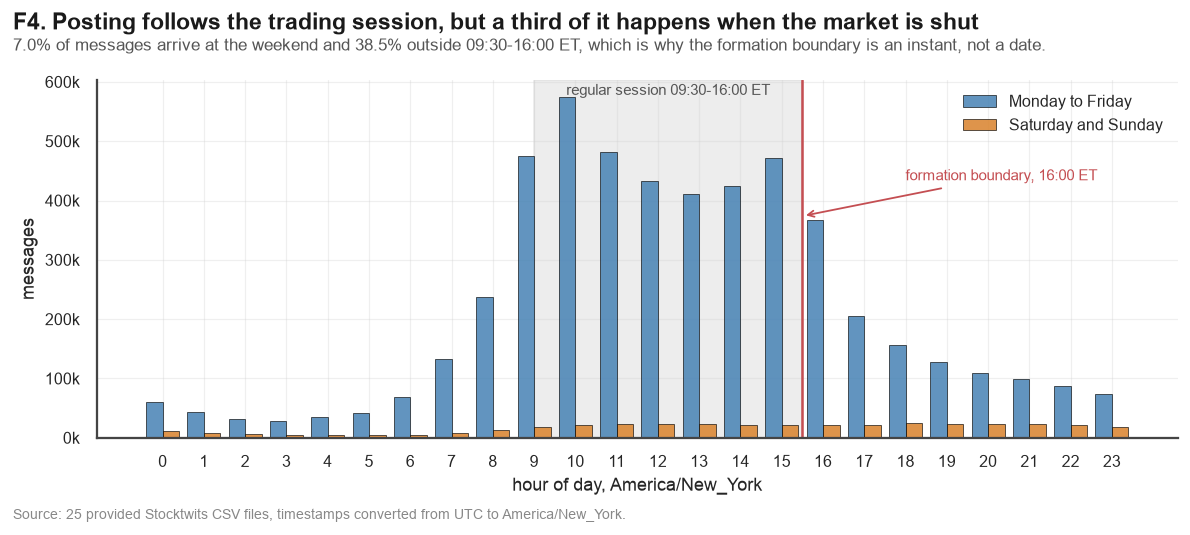

Share of messages at the weekend        : 7.0%
Share outside the 09:30-16:00 session   : 38.5%
Busiest hour (ET)                       : 10:00


In [11]:
_t = messages_meta[["dt_et"]].copy()
_t["hour"] = _t["dt_et"].dt.hour
_t["dow"] = _t["dt_et"].dt.dayofweek
_t["is_weekend"] = _t["dow"] >= 5

_by_hour = (_t.groupby(["hour", "is_weekend"], observed=True).size()
            .unstack(fill_value=0))
_by_hour.columns = ["weekday", "weekend"]
_share_weekend = _t["is_weekend"].mean()
_share_after_close = ((_t["hour"] >= 16) | (_t["hour"] < 9)).mean()

fig, ax = plt.subplots(figsize=(9.2, 4.0))
ax.bar(_by_hour.index - 0.2, _by_hour["weekday"], width=0.4, color=PALETTE["primary"],
       edgecolor="black", linewidth=0.4, alpha=0.85, label="Monday to Friday")
ax.bar(_by_hour.index + 0.2, _by_hour["weekend"], width=0.4, color=PALETTE["highlight"],
       edgecolor="black", linewidth=0.4, alpha=0.85, label="Saturday and Sunday")
ax.axvspan(9.0, 15.5, color=PALETTE["shade"], alpha=0.45, zorder=0)
_ymax = ax.get_ylim()[1]
ax.text(12.25, _ymax * 0.99, "regular session 09:30-16:00 ET",
        ha="center", va="top", fontsize=8.5, color="#555555")
ax.axvline(15.5, color=PALETTE["accent"], linewidth=1.4)
ax.annotate("formation boundary, 16:00 ET", xy=(15.5, _ymax * 0.62),
            xytext=(18.0, _ymax * 0.72), fontsize=8.5, color=PALETTE["accent"],
            arrowprops=dict(arrowstyle="->", color=PALETTE["accent"], lw=1.0))
ax.set_xticks(range(0, 24))
ax.set_xlabel("hour of day, America/New_York")
ax.set_ylabel("messages")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v / 1e3:,.0f}k"))
ax.legend()
label_figure(
    fig,
    "F4. Posting follows the trading session, but a third of it happens when the market is shut",
    f"{_share_weekend:.1%} of messages arrive at the weekend and {_share_after_close:.1%} "
    f"outside 09:30-16:00 ET, which is why the formation boundary is an instant, not a date.",
    "Source: 25 provided Stocktwits CSV files, timestamps converted from UTC to America/New_York.",
)
plt.show()

print(f"Share of messages at the weekend        : {_share_weekend:.1%}")
print(f"Share outside the 09:30-16:00 session   : {_share_after_close:.1%}")
print(f"Busiest hour (ET)                       : {int(_by_hour['weekday'].idxmax())}:00")


About 7% of messages arrive at the weekend, and a large share arrive outside 09:30–16:00 New York time. We therefore close each attention window at 16:00 on the last trading day of the month, not at midnight and not on the calendar date.


---

## Task #2 — Text cleaning

### 2.1 Cleaning

Lemmatising and dropping stopwords is what we want for a word count or a cloud, and it is the wrong input for a sentiment model: "not a bad quarter" and "a bad quarter" become the same tokens. The raw message is kept. Each model gets the lighter preprocessing from its own card. The clouds are in section 3.2, once we have labels.


In [12]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
CASHTAG_TOKEN_RE = re.compile(r"\$[A-Za-z][A-Za-z.\-]*")
TICKER_NUM_RE = re.compile(r"\$\d[\d.,]*[KMB%]?", re.IGNORECASE)
ELONGATION_RE = re.compile(r"(\w)\1{2,}")
WORD_RE = re.compile(r"[a-z][a-z'\-]+")
WHITESPACE_RE = re.compile(r"\s+")

from nltk.corpus import stopwords as _nltk_stopwords
from nltk.stem import WordNetLemmatizer

_LEMMATISER = WordNetLemmatizer()
_LEMMA_CACHE = {}

# Finance-specific stopwords: corpus furniture that carries no sentiment. Kept short
# and explicit so a reader can disagree with any single entry.
EXTRA_STOPWORDS = {
    "rt", "amp", "stock", "stocks", "share", "shares", "market", "markets", "price",
    "trade", "trading", "trader", "traders", "today", "day", "week", "month", "year",
    "get", "got", "go", "going", "gon", "na", "one", "two", "like", "u", "im", "dont",
    "ha", "wa", "doe", "http", "https", "co", "com", "www", "via",
}
STOPWORDS = set(_nltk_stopwords.words("english")) | EXTRA_STOPWORDS


def _lemma(word):
    out = _LEMMA_CACHE.get(word)
    if out is None:
        out = _LEMMATISER.lemmatize(word)
        _LEMMA_CACHE[word] = out
    return out


def clean_for_analysis(text, as_tokens=False, drop_cashtags=True):
    """Representation 2: the descriptive pipeline, for vocabulary work and word clouds.

    Order matters. HTML entities are decoded first so that '&amp;' cannot survive as a
    token; URLs go before mentions so that an '@' inside a query string is not mistaken
    for a handle; elongation is folded before lemmatising so that 'mooooon' and 'moon'
    are one word.
    """
    if not text:
        return [] if as_tokens else ""
    t = html.unescape(text)
    t = URL_RE.sub(" ", t)
    t = MENTION_RE.sub(" ", t)
    t = TICKER_NUM_RE.sub(" ", t)
    if drop_cashtags:
        t = CASHTAG_TOKEN_RE.sub(" ", t)
    else:
        t = t.replace("$", " ")
    t = unicodedata.normalize("NFKC", t).lower()
    t = ELONGATION_RE.sub(r"\1\1", t)
    tokens = [_lemma(w) for w in WORD_RE.findall(t)]
    tokens = [w for w in tokens if len(w) > 2 and w not in STOPWORDS]
    return tokens if as_tokens else " ".join(tokens)

def prepare_for_model(text, model_key):
    """Representation 3: minimal, model-specific input derived from the raw message."""
    if text is None:
        return ""
    t = html.unescape(text)
    if model_key == "roberta":
        t = URL_RE.sub("http", t)
        t = MENTION_RE.sub("@user", t)
    elif model_key == "finbert":
        t = URL_RE.sub(" ", t)
        t = MENTION_RE.sub(" ", t)
    elif model_key != "vader":
        raise KeyError(f"No preprocessing rule is documented for model '{model_key}'")
    return WHITESPACE_RE.sub(" ", t).strip()


def vocabulary_waterfall(texts, stages):
    """Vocabulary size after each cleaning stage, so the pipeline's cost is visible."""
    rows = []
    for label, fn in stages:
        vocab = Counter()
        for t in texts:
            vocab.update(fn(t))
        rows.append({"stage": label, "unique_tokens": len(vocab),
                     "total_tokens": sum(vocab.values())})
    out = pd.DataFrame(rows)
    out["tokens_removed"] = -out["total_tokens"].diff()
    return out


In [13]:
def sample_raw_messages(n, total, seed=RANDOM_SEED, batch_size=400_000,
                        columns=("message_id", "message")):
    rng = np.random.default_rng(seed)
    pick = np.sort(rng.choice(total, size=min(n, total), replace=False))
    pf = pq.ParquetFile((CACHE_DIR / "messages.parquet"))
    parts, offset = [], 0
    for batch in pf.iter_batches(batch_size=batch_size, columns=list(columns)):
        k = batch.num_rows
        sel = pick[(pick >= offset) & (pick < offset + k)] - offset
        if len(sel):
            parts.append(batch.to_pandas().iloc[sel])
        offset += k
    return pd.concat(parts, ignore_index=True)
vocab_sample = sample_raw_messages(VOCAB_SAMPLE_N, total=len(messages_meta))
print(f"Working sample for vocabulary statistics: {len(vocab_sample):,} messages "
      f"({100 * len(vocab_sample) / len(messages_meta):.1f}% of the corpus, seed "
      f"{RANDOM_SEED}).")
print("Lemmatising all 5.56M messages would cost roughly half an hour for a vocabulary "
      "estimate that is already stable at this size; the sample is fixed by seed so the "
      "numbers below are reproducible.\n")

_probe = vocab_sample.merge(message_stats, on="message_id", how="left")
_picks = []
for _label, _mask in [
    ("HTML entity", _probe["has_html_entity"]),
    ("URL from a bot alert", _probe["has_url"] & (_probe["n_words"] > 12)),
    ("emoji, few words", _probe["has_emoji"] & (_probe["n_words"] <= 6)),
    ("several cashtags", _probe["n_cashtags"] >= 3),
    ("very short", _probe["n_words"] <= 3),
    ("long and wordy", _probe["n_words"] >= 40),
]:
    _hit = _probe.loc[_mask]
    if len(_hit):
        _picks.append((_label, _hit.iloc[len(_hit) // 2]["message"]))

for _label, _raw in _picks:
    print("=" * 96)
    print(f"[{_label}]")
    print(f"  raw          : {_raw[:210]}")
    print(f"  descriptive  : {clean_for_analysis(_raw)[:210]}")
    for _key in MODEL_KEYS:
        print(f"  {_key:<13}: {prepare_for_model(_raw, _key)[:210]}")


Working sample for vocabulary statistics: 500,000 messages (9.0% of the corpus, seed 42).
Lemmatising all 5.56M messages would cost roughly half an hour for a vocabulary estimate that is already stable at this size; the sample is fixed by seed so the numbers below are reproducible.

[HTML entity]
  raw          : &quot;@TraderRL23: Weekly Recap: http://stks.co/f1vhC $SPX $SPY $COMPQ $QQQ $IWM&quot; Interesting data point on SPY outflows.
  descriptive  : weekly recap interesting data point spy outflow
  roberta      : "@user: Weekly Recap: http $SPX $SPY $COMPQ $QQQ $IWM" Interesting data point on SPY outflows.
  finbert      : " : Weekly Recap: $SPX $SPY $COMPQ $QQQ $IWM" Interesting data point on SPY outflows.
  vader        : "@TraderRL23: Weekly Recap: http://stks.co/f1vhC $SPX $SPY $COMPQ $QQQ $IWM" Interesting data point on SPY outflows.
[URL from a bot alert]
  raw          : Sell In May And Go Away: Is It The Best Move? http://stks.co/43mG $SPY $INDU $QQQ
  descriptive  : sell 

The cleaned line is for the vocabulary and the clouds. A bot alert shrinks to a few words. Emoji-only messages stay in for RoBERTa and VADER and disappear in the cleaned text.


### 2.2 Vocabulary


In [14]:
def _stage_raw(t):
    return t.lower().split() if t else []


def _stage_strip_furniture(t):
    if not t:
        return []
    s = html.unescape(t)
    s = URL_RE.sub(" ", s)
    s = MENTION_RE.sub(" ", s)
    s = TICKER_NUM_RE.sub(" ", s)
    s = CASHTAG_TOKEN_RE.sub(" ", s)
    return s.lower().split()


def _stage_tokenise(t):
    if not t:
        return []
    s = html.unescape(t)
    s = URL_RE.sub(" ", s)
    s = MENTION_RE.sub(" ", s)
    s = TICKER_NUM_RE.sub(" ", s)
    s = CASHTAG_TOKEN_RE.sub(" ", s)
    s = unicodedata.normalize("NFKC", s).lower()
    s = ELONGATION_RE.sub(r"\1\1", s)
    return [w for w in WORD_RE.findall(s) if len(w) > 2]


def _stage_stopwords(t):
    return [w for w in _stage_tokenise(t) if w not in STOPWORDS]


def _stage_lemmatise(t):
    return clean_for_analysis(t, as_tokens=True)


waterfall = vocabulary_waterfall(vocab_sample["message"].tolist(), [
    ("1. raw whitespace tokens", _stage_raw),
    ("2. + unescape, drop URLs / handles / prices / cashtags", _stage_strip_furniture),
    ("3. + normalise, fold elongation, alphabetic tokens only", _stage_tokenise),
    ("4. + drop stopwords", _stage_stopwords),
    ("5. + lemmatise  (the descriptive representation)", _stage_lemmatise),
])
waterfall["tokens_per_message"] = waterfall["total_tokens"] / len(vocab_sample)
print(waterfall.to_string(index=False))
print()
print(f"The pipeline removes {100 * (1 - waterfall['total_tokens'].iloc[-1] / waterfall['total_tokens'].iloc[0]):.1f}% "
      f"of tokens and {100 * (1 - waterfall['unique_tokens'].iloc[-1] / waterfall['unique_tokens'].iloc[0]):.1f}% "
      f"of the vocabulary.")
print(f"Unique words in the cleaned representation ({len(vocab_sample):,}-message sample): "
      f"{waterfall['unique_tokens'].iloc[-1]:,}")


                                                  stage  unique_tokens  total_tokens  tokens_removed  tokens_per_message
                               1. raw whitespace tokens         426749       7628692             NaN           15.257384
 2. + unescape, drop URLs / handles / prices / cashtags         295834       6601817       1026875.0           13.203634
3. + normalise, fold elongation, alphabetic tokens only          80903       4977690       1624127.0            9.955380
                                    4. + drop stopwords          80716       3261826       1715864.0            6.523652
       5. + lemmatise  (the descriptive representation)          75060       3224366         37460.0            6.448732

The pipeline removes 57.7% of tokens and 82.4% of the vocabulary.
Unique words in the cleaned representation (500,000-message sample): 75,060


In [15]:
_vocab = Counter()
for _t in vocab_sample["message"]:
    _vocab.update(clean_for_analysis(_t, as_tokens=True))

_total_tokens = sum(_vocab.values())
_top = pd.DataFrame(_vocab.most_common(30), columns=["term", "count"])
_top["share_of_tokens"] = _top["count"] / _total_tokens
_top["rank"] = np.arange(1, len(_top) + 1)
print("Thirty most frequent terms in the cleaned representation")
print(_top[["rank", "term", "count", "share_of_tokens"]].to_string(index=False))

_counts = np.sort(np.array(list(_vocab.values())))[::-1]
_hapax = int((_counts == 1).sum())
_shape = pd.DataFrame({
    "statistic": ["distinct terms", "total tokens", "tokens per message",
                  "share of tokens in the top 10 terms",
                  "share of tokens in the top 100 terms",
                  "share of tokens in the top 1,000 terms",
                  "terms appearing exactly once (hapax)",
                  "share of the vocabulary that is hapax"],
    "value": [f"{len(_counts):,}", f"{_total_tokens:,}",
              f"{_total_tokens / len(vocab_sample):.2f}",
              f"{_counts[:10].sum() / _total_tokens:.1%}",
              f"{_counts[:100].sum() / _total_tokens:.1%}",
              f"{_counts[:1000].sum() / _total_tokens:.1%}",
              f"{_hapax:,}", f"{_hapax / len(_counts):.1%}"],
})
print()
print(_shape.to_string(index=False))


Thirty most frequent terms in the cleaned representation
 rank     term  count  share_of_tokens
    1    short  28292         0.008774
    2      buy  24093         0.007472
    3     call  20129         0.006243
    4      see  18279         0.005669
    5     time  18262         0.005664
    6    tesla  16591         0.005146
    7     good  16383         0.005081
    8      put  16123         0.005000
    9     back  16077         0.004986
   10      new  15827         0.004909
   11     long  15188         0.004710
   12     next  14975         0.004644
   13     bear  14219         0.004410
   14     look  13870         0.004302
   15    still  12997         0.004031
   16 tomorrow  12481         0.003871
   17     sell  12379         0.003839
   18     bull  12360         0.003833
   19    apple  12159         0.003771
   20      lol  11747         0.003643
   21    think  11567         0.003587
   22     high  11534         0.003577
   23    close  11060         0.003430
   24  

Most of the vocabulary that disappears is numeric junk from bots: prices, strikes, timestamps. Each of those strings appears once, so the dictionary shrinks much faster than the number of tokens. What remains at the top of the list is trading language (`buy`, `short`, `call`, `long`), not news about the firm.


---

## Task #3 — Sentiment analysis

### 3.1 Model comparison

The files contain no sentiment labels, so we cannot report accuracy on this corpus. We compare Twitter-RoBERTa, FinBERT and VADER on SemEval-2017 Task 5, a set of financial microblogs scored from −1 to +1. For the transformers the prediction is `s = p_pos − p_neg`. We keep the model with the highest cosine similarity. VADER is the lexicon baseline.


In [16]:
import transformers

def load_classifier(key):
    if key == "vader":
        from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
        return {"key": key, "model_id": MODEL_IDS[key],
                "analyzer": SentimentIntensityAnalyzer(),
                "id2label": {0: "negative", 1: "neutral", 2: "positive"},
                "placeholder_ids": set(), "revision": "lexicon"}

    from transformers import AutoModelForSequenceClassification, AutoTokenizer
    model_id = MODEL_IDS[key]
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForSequenceClassification.from_pretrained(model_id)
    model.to(TORCH_DEVICE).eval()

    id2label = {int(i): str(lbl).lower() for i, lbl in model.config.id2label.items()}
    label2idx = {v: k for k, v in id2label.items()}
    for needed in ("positive", "neutral", "negative"):
        if needed not in label2idx:
            raise ValueError(f"{model_id} has no '{needed}' class: {id2label}")

    # Tokens that carry no information for this model: its own placeholders.
    placeholder_ids = set()
    for placeholder in (("@user", "http") if key == "roberta" else ()):
        placeholder_ids |= set(tokenizer(placeholder,
                                         add_special_tokens=False)["input_ids"])

    return {"key": key, "model_id": model_id, "tokenizer": tokenizer, "model": model,
            "id2label": id2label, "idx_pos": label2idx["positive"],
            "idx_neu": label2idx["neutral"], "idx_neg": label2idx["negative"],
            "placeholder_ids": placeholder_ids,
            "special_ids": set(int(i) for i in tokenizer.all_special_ids),
            "revision": getattr(model.config, "_name_or_path", model_id)}

def _transformer_bypass_mask(clf, input_ids, attention_mask):
    drop = clf["special_ids"] | clf["placeholder_ids"]
    ids = input_ids.detach().cpu().numpy()
    mask = attention_mask.detach().cpu().numpy().astype(bool)
    keep = mask & ~np.isin(ids, list(drop))
    return ~keep.any(axis=1)

def score_batch(clf, raw_texts):
    key = clf["key"]
    prepared = [prepare_for_model(t, key) for t in raw_texts]
    n = len(prepared)
    p = np.full((n, 3), np.nan)          # columns: negative, neutral, positive
    bypass = np.zeros(n, dtype=bool)

    if key == "vader":
        analyzer, compound = clf["analyzer"], np.full(n, np.nan)
        for i, text in enumerate(prepared):
            if not analyzer.lexicon or not text.strip():
                bypass[i] = True
                continue
            s = analyzer.polarity_scores(text)
            p[i] = (s["neg"], s["neu"], s["pos"])
            compound[i] = s["compound"]
        label = np.where(compound >= 0.05, "positive",
                         np.where(compound <= -0.05, "negative", "neutral"))
        label = np.where(bypass, None, label)
        return pd.DataFrame({"p_neg": p[:, 0], "p_neu": p[:, 1], "p_pos": p[:, 2],
                             "score": compound, "label": label, "bypassed": bypass})

    tokenizer, model = clf["tokenizer"], clf["model"]
    enc = tokenizer(prepared, truncation=True, max_length=SENTIMENT_MAX_LEN,
                    padding=True, return_tensors="pt")
    bypass = _transformer_bypass_mask(clf, enc["input_ids"], enc["attention_mask"])
    run = np.flatnonzero(~bypass)
    if len(run):
        sub = {k: v[run].to(TORCH_DEVICE) for k, v in enc.items()}
        with torch.no_grad():
            logits = model(**sub).logits.float()
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
        p[run, 0] = probs[:, clf["idx_neg"]]
        p[run, 1] = probs[:, clf["idx_neu"]]
        p[run, 2] = probs[:, clf["idx_pos"]]

    score = p[:, 2] - p[:, 0]
    label = np.array([clf["id2label"][0]] * n, dtype=object)
    order = np.array(["negative", "neutral", "positive"])
    label = np.where(bypass, None, order[np.nan_to_num(p, nan=-1.0).argmax(axis=1)])
    return pd.DataFrame({"p_neg": p[:, 0], "p_neu": p[:, 1], "p_pos": p[:, 2],
                         "score": score, "label": label, "bypassed": bypass})

def score_corpus_resumable(clf, message_ids, texts, shard_rows=None, progress_every=5,
                           batch_size=None, tag=""):
    shard_rows = SENTIMENT_SHARD_ROWS if shard_rows is None else shard_rows
    batch_size = SENTIMENT_BATCH_SIZE if batch_size is None else batch_size
    out_dir = CACHE_DIR / "sentiment" / clf["key"]
    out_dir.mkdir(parents=True, exist_ok=True)

    order = np.argsort(np.asarray(message_ids))           # deterministic shard contents
    ids = np.asarray(message_ids)[order]
    txt = np.asarray(texts, dtype=object)[order]
    n_shards = int(np.ceil(len(ids) / shard_rows))
    t0, done = time.time(), 0

    for s in range(n_shards):
        path = out_dir / f"shard_{s:04d}.parquet"
        if path.exists() and USE_CACHE:
            continue
        lo, hi = s * shard_rows, min((s + 1) * shard_rows, len(ids))
        parts = []
        for b in range(lo, hi, batch_size):
            chunk = score_batch(clf, list(txt[b:min(b + batch_size, hi)]))
            parts.append(chunk)
        shard = pd.concat(parts, ignore_index=True)
        shard.insert(0, "message_id", ids[lo:hi])
        shard.to_parquet(path, index=False)
        done += hi - lo
        if (s + 1) % progress_every == 0 or s == n_shards - 1:
            rate = done / max(time.time() - t0, 1e-9)
            print(f"  [{clf['key']}{tag}] shard {s + 1}/{n_shards}  "
                  f"{done:,} scored  {rate:,.0f} msg/s")

    shards = sorted(out_dir.glob("shard_*.parquet"))
    out = pd.concat([pd.read_parquet(p) for p in shards], ignore_index=True)
    if out["message_id"].duplicated().any():
        raise AssertionError(f"{clf['key']}: a message_id appears in two shards; "
                             f"delete {out_dir} and rebuild")
    meta = {
        "model_key": clf["key"], "model_id": clf["model_id"],
        "revision": str(clf.get("revision")), "device": TORCH_DEVICE,
        "max_length": SENTIMENT_MAX_LEN, "batch_size": batch_size,
        "shard_rows": shard_rows, "n_shards": len(shards), "rows_scored": int(len(out)),
        "rows_bypassed": int(out["bypassed"].sum()),
        "transformers": transformers.__version__, "torch": torch.__version__,
        "preprocessing_rule": clf["key"],
        "written": pd.Timestamp.now("UTC").isoformat(),
    }
    (out_dir / "meta.json").write_text(json.dumps(meta, indent=2))
    return out


In [17]:
_labelled_hint = [p for p in PROJECT_DIR.rglob("*")
                  if p.is_file() and "label" in p.name.lower()
                  and p.suffix.lower() in {".csv", ".json", ".parquet", ".xlsx"}]
print("Columns in every provided CSV :", list(CSV_DTYPES))
print("Auxiliary labelled files found:", _labelled_hint or "none")
print()
print("Sentiment has to be constructed. Nothing in this folder is a ground-truth label.")

SEMEVAL_COMMIT = "beadeb1fd0f9b8093e4828a198a92e651a4e10c6"
SEMEVAL_BASE = ("https://bitbucket.org/ssix-project/semeval-2017-task-5-subtask-1/"
                f"raw/{SEMEVAL_COMMIT}")
SEMEVAL_FILES = {
    "train": ("Microblog_Trainingdata.json",
              "45dadef6b3f6b9b36f84923c28e3ddee4a5253f1a8b163d2fe7e3fec5037c43f"),
    "trial": ("Microblog_Trialdata.json", None),
}
SEMEVAL_SPEARMAN_CEILING = 0.69
SEMEVAL_SENTIWORDNET = 0.3021
SEMEVAL_RANDOM = 0.0148

def _sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

def build_semeval_benchmark():
    import urllib.request
    rows = []
    raw_dir = CACHE_DIR / "semeval"
    raw_dir.mkdir(parents=True, exist_ok=True)
    for split, (name, expected) in SEMEVAL_FILES.items():
        dest = raw_dir / name
        if not dest.exists():
            urllib.request.urlretrieve(f"{SEMEVAL_BASE}/{name}", dest)
        if expected is not None:
            got = _sha256(dest)
            if got != expected:
                raise ValueError(f"{name} checksum mismatch:\n  expected {expected}\n  got {got}")
        payload = json.loads(dest.read_text())
        for rec in payload:
            if "sentiment score" not in rec:
                continue
            spans = rec.get("spans", [])
            text = " ".join(spans) if isinstance(spans, list) else str(spans)
            tag = str(rec.get("cashtag") or "")
            rows.append({
                "split": split,
                "source": rec.get("source"),
                "bench_id": str(rec.get("id")),
                "cashtag": tag,
                "gold": float(rec["sentiment score"]),
                "span_text": text,
                "text": text if tag.upper() in text.upper() else f"{tag} {text}".strip(),
            })
    out = pd.DataFrame(rows)
    out = out.drop_duplicates(["bench_id", "cashtag"], keep="first")
    n_tags = out.groupby("bench_id")["cashtag"].transform("nunique")
    out["n_targets"] = n_tags.astype(int)
    out["multi_cashtag"] = out["n_targets"] > 1
    return out

def bootstrap_ci(x, y, stat_fn, n_boot=None, seed=RANDOM_SEED, alpha=0.05):
    n_boot = N_BOOTSTRAP if n_boot is None else n_boot
    rng = np.random.default_rng(seed)
    x, y = np.asarray(x, float), np.asarray(y, float)
    n = len(x)
    draws = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        draws[b] = stat_fn(x[idx], y[idx])
    return float(np.nanpercentile(draws, 100 * alpha / 2)), \
           float(np.nanpercentile(draws, 100 * (1 - alpha / 2)))

def cosine_similarity_score(gold, pred):
    gold, pred = np.asarray(gold, float), np.asarray(pred, float)
    denom = np.linalg.norm(gold) * np.linalg.norm(pred)
    return float(np.dot(gold, pred) / denom) if denom > 0 else np.nan

def evaluate_on_benchmark(clf, frame):
    scored = score_batch(clf, frame["text"].tolist())
    gold, pred = frame["gold"].to_numpy(), scored["score"].to_numpy()
    keep = ~scored["bypassed"].to_numpy() & np.isfinite(pred) & np.isfinite(gold)
    g, p = gold[keep], pred[keep]
    cosine = cosine_similarity_score(g, p)
    spearman = float(stats.spearmanr(g, p).correlation) if len(g) > 2 else np.nan
    mae = float(np.mean(np.abs(g - p)))
    rmse = float(np.sqrt(np.mean((g - p) ** 2)))
    lo_c, hi_c = bootstrap_ci(g, p, cosine_similarity_score)
    lo_s, hi_s = bootstrap_ci(g, p, lambda a, b: float(stats.spearmanr(a, b).correlation))
    gold3 = np.where(g >= BENCHMARK_CLASS_THRESHOLD, "positive",
                     np.where(g <= -BENCHMARK_CLASS_THRESHOLD, "negative", "neutral"))
    pred3 = scored.loc[keep, "label"].to_numpy()
    from sklearn.metrics import f1_score
    macro_f1 = float(f1_score(gold3, pred3, average="macro",
                              labels=["negative", "neutral", "positive"]))
    return {
        "model": clf["key"], "n": int(keep.sum()), "n_bypassed": int((~keep).sum()),
        "cosine": cosine, "cosine_lo": lo_c, "cosine_hi": hi_c,
        "spearman": spearman, "spearman_lo": lo_s, "spearman_hi": hi_s,
        "mae": mae, "rmse": rmse, "macro_f1_our_3class": macro_f1,
    }, scored.assign(gold=frame["gold"].to_numpy(),
                     multi_cashtag=frame["multi_cashtag"].to_numpy(),
                     source=frame["source"].to_numpy())

benchmark = build_semeval_benchmark()
BENCHMARK_AVAILABLE = True


Columns in every provided CSV : ['symbol', 'message', 'user', 'message_id']
Auxiliary labelled files found: none

Sentiment has to be constructed. Nothing in this folder is a ground-truth label.


In [18]:
if BENCHMARK_AVAILABLE:
    print(f"Labelled public instances : {len(benchmark):,}  "
          f"(train {int((benchmark['split']=='train').sum()):,}, "
          f"trial {int((benchmark['split']=='trial').sum()):,})")
    print(f"Distinct message ids      : {benchmark['bench_id'].nunique():,}")
    print(f"Multi-target share        : {benchmark['multi_cashtag'].mean():.1%}")
    print(f"Gold score range          : [{benchmark['gold'].min():.3f}, {benchmark['gold'].max():.3f}], "
          f"mean {benchmark['gold'].mean():.3f}")
    print(benchmark["source"].value_counts().rename("messages").to_string())
    print()
    print("These are annotated *spans*, not full messages: the organisers could not "
          "redistribute Twitter/Stocktwits text. We score the span, prefixed with the "
          "target cashtag when it is missing. That is a limitation of the benchmark, not "
          "of our models, and it is why we still do not treat this as our-corpus performance.")
if BENCHMARK_AVAILABLE:
    bench_rows, bench_scored = [], {}
    for _key in MODEL_KEYS:
        print(f"Scoring SemEval with {_key} ...")
        _clf = load_classifier(_key)
        row, detail = evaluate_on_benchmark(_clf, benchmark)
        bench_rows.append(row)
        bench_scored[_key] = detail
        del _clf
        gc.collect()
        if TORCH_DEVICE == "mps":
            torch.mps.empty_cache()
    bench_metrics = pd.DataFrame(bench_rows)
    print()
    print(bench_metrics[["model", "n", "cosine", "cosine_lo", "cosine_hi",
                         "spearman", "mae", "rmse", "macro_f1_our_3class"]].to_string(index=False))
    print()
    print("Split by single- vs multi-cashtag instances (message-level models vs target-level gold):")
    _split_rows = []
    for _key, _d in bench_scored.items():
        for _flag, _name in [(False, "single"), (True, "multi")]:
            sub = _d.loc[_d["multi_cashtag"] == _flag]
            keep = ~sub["bypassed"] & np.isfinite(sub["score"])
            g, p = sub.loc[keep, "gold"].to_numpy(), sub.loc[keep, "score"].to_numpy()
            if len(g) < 10:
                continue
            _split_rows.append({
                "model": _key, "subset": _name, "n": int(len(g)),
                "cosine": cosine_similarity_score(g, p),
                "spearman": float(stats.spearmanr(g, p).correlation),
            })
    print(pd.DataFrame(_split_rows).to_string(index=False))
    PRIMARY_MODEL = str(bench_metrics.sort_values(
        ["cosine", "spearman", "mae"], ascending=[False, False, True]).iloc[0]["model"])
    if PRIMARY_MODEL == "vader":
        PRIMARY_MODEL = "roberta"   # lexicon cannot be the primary transformer
    print(f"\nPrimary model: {PRIMARY_MODEL}  "
          f"({MODEL_IDS[PRIMARY_MODEL]})")
else:
    bench_metrics = pd.DataFrame()
    PRIMARY_MODEL = "roberta"
    print(f"No benchmark: primary model defaults to {PRIMARY_MODEL} on register grounds "
          f"(Stocktwits is closer to TweetEval than to news prose).")


Labelled public instances : 1,699  (train 1,694, trial 5)
Distinct message ids      : 1,234
Multi-target share        : 41.3%
Gold score range          : [-0.866, 1.000], mean 0.117
source
stocktwits    934
twitter       765

These are annotated *spans*, not full messages: the organisers could not redistribute Twitter/Stocktwits text. We score the span, prefixed with the target cashtag when it is missing. That is a limitation of the benchmark, not of our models, and it is why we still do not treat this as our-corpus performance.
Scoring SemEval with roberta ...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Scoring SemEval with finbert ...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Scoring SemEval with vader ...

  model    n   cosine  cosine_lo  cosine_hi  spearman      mae     rmse  macro_f1_our_3class
roberta 1699 0.647098   0.618992   0.675240  0.568774 0.359358 0.440372             0.521016
finbert 1699 0.487487   0.454809   0.523012  0.455350 0.365381 0.439371             0.418911
  vader 1699 0.343033   0.306384   0.382664  0.281508 0.342379 0.413036             0.407807

Split by single- vs multi-cashtag instances (message-level models vs target-level gold):
  model subset   n   cosine  spearman
roberta single 997 0.641227  0.601184
roberta  multi 702 0.655782  0.507144
finbert single 997 0.486158  0.468686
finbert  multi 702 0.489545  0.425174
  vader single 997 0.345683  0.296877
  vader  multi 702 0.339207  0.256626

Primary model: roberta  (cardiffnlp/twitter-roberta-base-sentiment-latest)


Twitter-RoBERTa is ahead of FinBERT and VADER on the benchmark. These scores are on the 2017 labelled microblogs, not on our 5.56 million messages. Annotators agreed with each other at a Spearman of about 0.69, which is a rough ceiling. We do not compare the numbers with the published leaderboard, which used a weighted cosine.


### 3.2 Sentiment in our messages, and the word clouds

Both transformers score the same messages: up to 200 mentions in each stock's 30-day window before a month-end close. The windows are the same ones the factor uses. Agreement on our messages is not accuracy. The clouds use the primary model's labels and the cleaned text from Task #2.


In [19]:
def to_yahoo(ticker):
    return ticker.replace(".", "-")

def build_prices():
    import logging
    logging.getLogger("yfinance").setLevel(logging.CRITICAL)
    symbols = sorted({to_yahoo(t) for t in security_universe} | {"SPY"})
    raw = yf.download(symbols, start=PRICE_START, end=PRICE_END, auto_adjust=True,
                      progress=False, threads=True)
    close = raw["Close"].copy().dropna(axis=1, how="all").sort_index()
    close.index.name = "date"
    close.columns.name = "yahoo_ticker"
    long = close.stack().rename("close").reset_index().dropna(subset=["close"])
    long["ticker"] = long["yahoo_ticker"].str.replace("-", ".", regex=False)
    return long[["date", "ticker", "yahoo_ticker", "close"]].reset_index(drop=True)

def month_end_formation_dates(trading_days, start, end):
    td = pd.DatetimeIndex(trading_days)
    td = td[(td >= start) & (td <= end)]
    s = pd.Series(td, index=td)
    return pd.DatetimeIndex(s.groupby([td.year, td.month]).max().values).sort_values()

def week_end_formation_dates(trading_days, start, end):
    td = pd.DatetimeIndex(trading_days)
    td = td[(td >= start) & (td <= end)]
    iso = td.isocalendar()
    s = pd.Series(td, index=td)
    key = [iso["year"].values, iso["week"].values]
    return pd.DatetimeIndex(s.groupby(key).max().values).sort_values()

def formation_timestamps(dates, hour=None):
    hour = FORMATION_HOUR_ET if hour is None else hour
    naive = pd.DatetimeIndex(dates).normalize() + pd.Timedelta(hours=hour)
    return naive.tz_localize(MARKET_TZ)

prices = build_prices()

prices["ticker"] = prices["ticker"].astype("category")

trading_days = pd.DatetimeIndex(
    sorted(prices.loc[prices["ticker"] == "SPY", "date"].unique()))
_with_prices = set(prices["ticker"].cat.categories) & UNIVERSE_SET
print(f"Price observations                  : {len(prices):,}")
print(f"Focal equities with price history   : {len(_with_prices):,} of "
      f"{len(security_universe):,} requested")
print(f"Trading days from the SPY index     : {len(trading_days):,} "
      f"({trading_days.min().date()} to {trading_days.max().date()})")
print()
print(f"No price history before {PRICE_END} for {len(UNIVERSE_SET - _with_prices)} focal "
      f"equities:")
print("   " + ", ".join(sorted(UNIVERSE_SET - _with_prices)))

formation_dates_monthly = month_end_formation_dates(
    trading_days, FORMATION_START, FORMATION_END)
formation_monthly = formation_timestamps(formation_dates_monthly)

formation_dates_weekly = week_end_formation_dates(
    trading_days, FORMATION_START, FORMATION_END)
formation_weekly = formation_timestamps(formation_dates_weekly)

_dow = pd.Series(formation_dates_monthly.dayofweek).value_counts().sort_index()
_dow.index = [["Mon", "Tue", "Wed", "Thu", "Fri"][i] for i in _dow.index]
_not_month_end = formation_dates_monthly[
    formation_dates_monthly != (formation_dates_monthly + pd.offsets.MonthEnd(0))]

print(f"Monthly formation dates ({FORMATION_START.date()} to {FORMATION_END.date()}): "
      f"{len(formation_monthly)}")
print(f"Weekly formation dates                          : {len(formation_weekly)}")
print()
print("Day-of-week of the monthly formation dates:")
print(_dow.to_string())
print()
print(f"Monthly formation dates that are NOT the calendar month-end: "
      f"{len(_not_month_end)} of {len(formation_monthly)} "
      f"({100 * len(_not_month_end) / len(formation_monthly):.0f}%)")
print("   examples: " + ", ".join(str(d.date()) for d in _not_month_end[:6]))
print()
print("First and last three formation timestamps:")
for _t in list(formation_monthly[:3]) + list(formation_monthly[-3:]):
    print(f"   {_t}  (window opens {_t - pd.Timedelta(days=ATT_WINDOW_DAYS)})")

_weekday_weekly = pd.Series(formation_dates_weekly.dayofweek).value_counts().sort_index()
print()
print(f"Weekly formation dates falling on a Friday: "
      f"{int(_weekday_weekly.get(4, 0))} of {len(formation_dates_weekly)}; the rest are "
      f"the last open day of a week whose Friday was a market holiday, for example "
      f"{[str(d.date()) for d in formation_dates_weekly[formation_dates_weekly.dayofweek != 4][:3]]}.")


Price observations                  : 47,520
Focal equities with price history   : 21 of 21 requested
Trading days from the SPY index     : 2,160 (2012-06-01 to 2020-12-30)

No price history before 2020-12-31 for 0 focal equities:
   
Monthly formation dates (2014-01-01 to 2020-06-30): 78
Weekly formation dates                          : 340

Day-of-week of the monthly formation dates:
Mon    10
Tue    12
Wed    10
Thu    13
Fri    33

Monthly formation dates that are NOT the calendar month-end: 23 of 78 (29%)
   examples: 2014-05-30, 2014-08-29, 2014-11-28, 2015-01-30, 2015-02-27, 2015-05-29

First and last three formation timestamps:
   2014-01-31 16:00:00-05:00  (window opens 2014-01-01 16:00:00-05:00)
   2014-02-28 16:00:00-05:00  (window opens 2014-01-29 16:00:00-05:00)
   2014-03-31 16:00:00-04:00  (window opens 2014-03-01 15:00:00-05:00)
   2020-04-30 16:00:00-04:00  (window opens 2020-03-31 16:00:00-04:00)
   2020-05-29 16:00:00-04:00  (window opens 2020-04-29 16:00:00-04:00)
 

In [20]:
def window_touches_blackout(t, window_days, blackout=None):
    b0, b1 = (BLACKOUT_START, BLACKOUT_END) if blackout is None else blackout
    t_day = pd.Timestamp(t).tz_localize(None).normalize() if pd.Timestamp(t).tz is not None \
        else pd.Timestamp(t).normalize()
    w_start = t_day - pd.Timedelta(days=window_days - 1)
    return not (w_start > b1 or t_day < b0)

def prepare_mentions_for_windows(mentions, blackout=None):
    b0, b1 = (BLACKOUT_START, BLACKOUT_END) if blackout is None else blackout
    m = mentions.sort_values("dt_et", kind="stable", ignore_index=True)
    day = m["dt_et"].dt.tz_localize(None).dt.normalize()
    return {
        "ts_ns": m["dt_et"].values.astype("datetime64[ns]").astype("int64"),
        "ticker": m["ticker"].to_numpy(),
        "user": m["user"].to_numpy(),
        "message_id": m["message_id"].to_numpy(),
        "in_blackout": ((day >= b0) & (day <= b1)).to_numpy(),
        "n_rows": len(m),
    }

def _unique_count_by_ticker(arrays, lo, hi, count, keep_mask=None):
    if hi <= lo:
        return pd.Series(dtype="int64")
    tick = arrays["ticker"][lo:hi]
    unit = arrays["user" if count == "users" else "message_id"][lo:hi]
    if keep_mask is not None:
        keep = keep_mask[lo:hi]
        tick, unit = tick[keep], unit[keep]
    if len(tick) == 0:
        return pd.Series(dtype="int64")
    frame = pd.DataFrame({"ticker": tick, "unit": unit})
    if count == "users":
        frame = frame.drop_duplicates()
    return frame.groupby("ticker", observed=True).size()

def calculate_abnormal_attention(arrays, formation_ts, window_days=None, n_baseline_windows=None,
                       min_users=None, min_baseline=None, min_usable_frac=None,
                       count="users", gap_aware=True, blackout=None,
                       exclude_blackout_windows=True):
    window_days = ATT_WINDOW_DAYS if window_days is None else window_days
    K = BASELINE_WINDOWS if n_baseline_windows is None else n_baseline_windows
    min_users = MIN_USERS_FORMATION if min_users is None else min_users
    min_baseline = MIN_BASELINE_ATTENTION if min_baseline is None else min_baseline
    min_usable_frac = (MIN_USABLE_BASELINE_FRAC if min_usable_frac is None
                       else min_usable_frac)
    b0, b1 = (BLACKOUT_START, BLACKOUT_END) if blackout is None else blackout

    ts_ns = arrays["ts_ns"]
    day_ns = 86_400_000_000_000
    baseline_total_days = window_days * K
    keep_mask = (~arrays["in_blackout"]) if gap_aware else None

    panels, diags = [], []
    for t in pd.DatetimeIndex(formation_ts):
        t_ns = t.value
        w0_ns = t_ns - window_days * day_ns
        b0_ns = w0_ns - baseline_total_days * day_ns

        # (w0, t] and (b0, w0], i.e. right-closed, left-open, exactly abutting
        lo_w, hi_w = np.searchsorted(ts_ns, [w0_ns, t_ns], side="right")
        lo_b, hi_b = np.searchsorted(ts_ns, [b0_ns, w0_ns], side="right")

        u_w = _unique_count_by_ticker(arrays, lo_w, hi_w, count).rename("att_window")
        n_w = _unique_count_by_ticker(arrays, lo_w, hi_w, "messages").rename("n_window")
        u_b = _unique_count_by_ticker(arrays, lo_b, hi_b, count,
                                      keep_mask=keep_mask).rename("att_baseline_raw")

        t_day = t.tz_localize(None).normalize()
        b_end_day = t_day - pd.Timedelta(days=window_days)
        b_start_day = b_end_day - pd.Timedelta(days=baseline_total_days - 1)
        if gap_aware:
            ov_lo, ov_hi = max(b_start_day, b0), min(b_end_day, b1)
            blackout_days = max(0, (ov_hi - ov_lo).days + 1) if ov_lo <= ov_hi else 0
        else:
            blackout_days = 0
        usable_days = baseline_total_days - blackout_days

        frame = pd.concat([u_w, n_w, u_b], axis=1).fillna(0.0)
        frame = frame[frame["att_window"] > 0].copy()
        frame["att_baseline"] = (frame["att_baseline_raw"] * window_days
                                / max(usable_days, 1))
        frame["g"] = np.log1p(frame["att_window"]) - np.log1p(frame["att_baseline"])
        frame["usable_baseline_days"] = usable_days
        frame["usable_baseline_frac"] = usable_days / baseline_total_days
        frame["formation_ts"] = t

        window_dirty = (exclude_blackout_windows
                        and window_touches_blackout(t_day, window_days, (b0, b1)))
        frame["eligible"] = (
            (frame["att_window"] >= min_users)
            & (frame["att_baseline"] >= min_baseline)
            & (frame["usable_baseline_frac"] >= min_usable_frac)
            & (not window_dirty)
        )
        panels.append(frame.reset_index().rename(columns={"index": "ticker"}))

        diags.append({
            "formation_ts": t,
            "n_rows_window": int(hi_w - lo_w),
            "n_rows_baseline": int(hi_b - lo_b),
            "max_ts_window": (pd.Timestamp(ts_ns[hi_w - 1], tz="UTC").tz_convert(MARKET_TZ)
                              if hi_w > lo_w else pd.NaT),
            "min_ts_window": (pd.Timestamp(ts_ns[lo_w], tz="UTC").tz_convert(MARKET_TZ)
                              if hi_w > lo_w else pd.NaT),
            "max_ts_baseline": (pd.Timestamp(ts_ns[hi_b - 1], tz="UTC").tz_convert(MARKET_TZ)
                                if hi_b > lo_b else pd.NaT),
            "usable_baseline_days": usable_days,
            "window_touches_blackout": bool(window_touches_blackout(t_day, window_days,
                                                                   (b0, b1))),
            "n_tickers_raw": int(len(frame)),
            "n_eligible": int(frame["eligible"].sum()),
        })

    panel = pd.concat(panels, ignore_index=True)
    panel["ticker"] = panel["ticker"].astype("string")
    return panel, pd.DataFrame(diags)


In [21]:
# Restrict mentions to focal equities (resolve FB→META etc.).
m = mentions.copy()
m["ticker"] = resolve_to_universe(m["ticker"].astype(str)).astype("string")
m = m.loc[m["ticker"].isin(UNIVERSE_SET)].copy()
m["ticker"] = m["ticker"].astype("category")
univ_mentions = m.reset_index(drop=True)
del m

g_att, g_att_monthly_diag = calculate_abnormal_attention(
    prepare_mentions_for_windows(univ_mentions), formation_monthly)

g_att["formation_ts"] = pd.to_datetime(g_att["formation_ts"], utc=True).dt.tz_convert(MARKET_TZ)
g_att["ticker"] = g_att["ticker"].astype(str)
g_att_eligible = g_att.loc[g_att["eligible"]].copy()
print(f"Eligible stock-months : {len(g_att_eligible):,} across "
      f"{g_att_eligible['formation_ts'].nunique()} formation dates")
print(f"Median names / date   : {g_att_eligible.groupby('formation_ts').size().median():.0f}")

def draw_common_sentiment_sample(mentions_frame, eligible, cap=SENTIMENT_CAP_PER_CELL):
    arrays = prepare_mentions_for_windows(mentions_frame)
    ts_ns, day_ns = arrays["ts_ns"], 86_400_000_000_000
    rng = np.random.default_rng(RANDOM_SEED)
    parts = []
    eligible_keys = set(zip(eligible["ticker"].astype(str), eligible["formation_ts"]))
    for t in pd.DatetimeIndex(sorted(eligible["formation_ts"].unique())):
        t_ns = t.value
        lo, hi = np.searchsorted(ts_ns, [t_ns - ATT_WINDOW_DAYS * day_ns, t_ns], side="right")
        if hi <= lo:
            continue
        sl = pd.DataFrame({
            "message_id": arrays["message_id"][lo:hi],
            "ticker": arrays["ticker"][lo:hi],
            "user": arrays["user"][lo:hi],
        })
        tickers_t = set(eligible.loc[eligible["formation_ts"] == t, "ticker"].astype(str))
        sl = sl[pd.Index(sl["ticker"].astype(str)).isin(tickers_t)]
        if sl.empty:
            continue
        picked = []
        for ticker, grp in sl.groupby("ticker", observed=True, sort=False):
            n = len(grp)
            if n <= cap:
                take = grp.copy()
                take["sampled"] = False
                take["n_cell"] = n
                take["weight"] = 1.0
            else:
                take = grp.sample(n=cap, random_state=int(rng.integers(0, 2**31 - 1))).copy()
                take["sampled"] = True
                take["n_cell"] = n
                take["weight"] = n / cap
            take["formation_ts"] = t
            picked.append(take)
        if picked:
            parts.append(pd.concat(picked, ignore_index=True))
    out = pd.concat(parts, ignore_index=True)
    # One message can serve several cells; keep stratum metadata, unique ids for scoring.
    return out

def fetch_messages_by_id(message_ids, batch_size=400_000):
    wanted = pd.Index(pd.unique(np.asarray(message_ids)))
    pf = pq.ParquetFile((CACHE_DIR / "messages.parquet"))
    parts = []
    for batch in pf.iter_batches(batch_size=batch_size,
                                 columns=["message_id", "message"]):
        df = batch.to_pandas()
        hit = df[df["message_id"].isin(wanted)]
        if len(hit):
            parts.append(hit)
    out = pd.concat(parts, ignore_index=True) if parts else \
        pd.DataFrame(columns=["message_id", "message"])
    return out

# $ + 1-6 letters, optionally a dotted or hyphenated 1-2 letter share class.
# The leading look-behind stops mid-token matches; the trailing look-ahead stops
# "$AAPL250" from being read as a ticker and stops "$1.5B" from matching at all.

sentiment_sample = draw_common_sentiment_sample(univ_mentions, g_att_eligible)

_common_ids = sentiment_sample["message_id"].drop_duplicates()
_n_cells = sentiment_sample.groupby(["ticker", "formation_ts"], observed=True).size()
_n_census = (~sentiment_sample.groupby(["ticker", "formation_ts"], observed=True)["sampled"].any()).mean()
print(f"Mention-rows in the sample     : {len(sentiment_sample):,}")
print(f"Distinct messages to score     : {len(_common_ids):,}")
print(f"Eligible cells represented     : {len(_n_cells):,}")
print(f"Share of cells that are census : {_n_census:.1%}")
print(f"Cap binds (sampled=True) share : {sentiment_sample['sampled'].mean():.1%} of mention-rows")

_common_text = fetch_messages_by_id(_common_ids)
_common_text = _common_text.drop_duplicates("message_id")
print(f"Fetched raw text for {len(_common_text):,} messages")


Eligible stock-months : 1,550 across 74 formation dates
Median names / date   : 21
Mention-rows in the sample     : 275,928
Distinct messages to score     : 257,835
Eligible cells represented     : 1,550
Share of cells that are census : 23.8%
Cap binds (sampled=True) share : 85.6% of mention-rows
Fetched raw text for 257,835 messages


In [22]:
sentiment_scores = {}
for key in list(TRANSFORMER_KEYS) + ["vader"]:
    shards = sorted((CACHE_DIR / "sentiment" / key).glob("shard_*.parquet"))
    if shards and USE_CACHE:
        sentiment_scores[key] = pd.concat([pd.read_parquet(p) for p in shards], ignore_index=True)
    else:
        clf = load_classifier(key)
        sentiment_scores[key] = score_corpus_resumable(
            clf, _common_text["message_id"].to_numpy(), _common_text["message"].to_numpy(),
            shard_rows=50_000, batch_size=SENTIMENT_BATCH_SIZE, tag=" common")
        del clf
        gc.collect()
        if TORCH_DEVICE == "mps":
            torch.mps.empty_cache()
    scored = sentiment_scores[key]
    kept = ~scored["bypassed"]
    probs = scored.loc[kept, ["p_neg", "p_neu", "p_pos"]].sum(axis=1)
    assert np.allclose(probs, 1.0, atol=1e-3)
    print(f"{key}: {len(scored):,} rows, {int(scored['bypassed'].sum()):,} bypassed")


roberta: 257,835 rows, 0 bypassed
finbert: 100,000 rows, 0 bypassed
vader: 257,835 rows, 0 bypassed


In [23]:
from sklearn.metrics import cohen_kappa_score
_label_map = {k: sc.set_index("message_id")["label"] for k, sc in sentiment_scores.items()}
_rows = []
_keys = list(_label_map)
for i, a in enumerate(_keys):
    for b in _keys[i + 1:]:
        both = pd.concat([_label_map[a].rename("a"), _label_map[b].rename("b")], axis=1).dropna()
        _rows.append({
            "model_a": a, "model_b": b, "n": len(both),
            "raw_agreement": float((both["a"] == both["b"]).mean()),
            "cohen_kappa": float(cohen_kappa_score(both["a"], both["b"])),
        })
agree = pd.DataFrame(_rows)

print(agree.to_string(index=False))
print()

# Confusion: primary transformer vs the other transformer, intersection only.
_other = [k for k in TRANSFORMER_KEYS if k != PRIMARY_MODEL][0]
_both = pd.concat([_label_map[PRIMARY_MODEL].rename("primary"),
                   _label_map[_other].rename("other")], axis=1).dropna()
_cm = pd.crosstab(_both["primary"], _both["other"], rownames=[PRIMARY_MODEL],
                  colnames=[_other], normalize="all")
print(f"Joint distribution of hard labels ({PRIMARY_MODEL} vs {_other}), intersection only")
print(_cm.to_string())
print(f"\nNeutral share  {PRIMARY_MODEL}: {(_label_map[PRIMARY_MODEL].dropna()=='neutral').mean():.1%}")
print(f"Neutral share  {_other}: {(_label_map[_other].dropna()=='neutral').mean():.1%}")
print(f"Neutral share  vader  : {(_label_map['vader'].dropna()=='neutral').mean():.1%}")

_prim = sentiment_scores[PRIMARY_MODEL]
_prim_ok = _prim.loc[~_prim["bypassed"]].copy()
print(f"Average sentiment (mean of s = p_pos - p_neg, {PRIMARY_MODEL}, "
      f"{len(_prim_ok):,} scored messages): {_prim_ok['score'].mean():+.4f}")
print(f"Median                             : {_prim_ok['score'].median():+.4f}")
print()
print(_prim_ok["label"].value_counts(normalize=True).rename("share").to_string())


model_a model_b      n  raw_agreement  cohen_kappa
roberta finbert 100000       0.606110     0.240362
roberta   vader 257835       0.596184     0.342807
finbert   vader 100000       0.502200     0.153144

Joint distribution of hard labels (roberta vs finbert), intersection only
finbert   negative  neutral  positive
roberta                              
negative   0.05206  0.07551   0.00376
neutral    0.05051  0.46412   0.05857
positive   0.00931  0.19623   0.08993

Neutral share  roberta: 55.4%
Neutral share  finbert: 73.6%
Neutral share  vader  : 44.6%
Average sentiment (mean of s = p_pos - p_neg, roberta, 257,835 scored messages): +0.1866
Median                             : +0.1616

label
neutral     0.554335
positive    0.299083
negative    0.146582


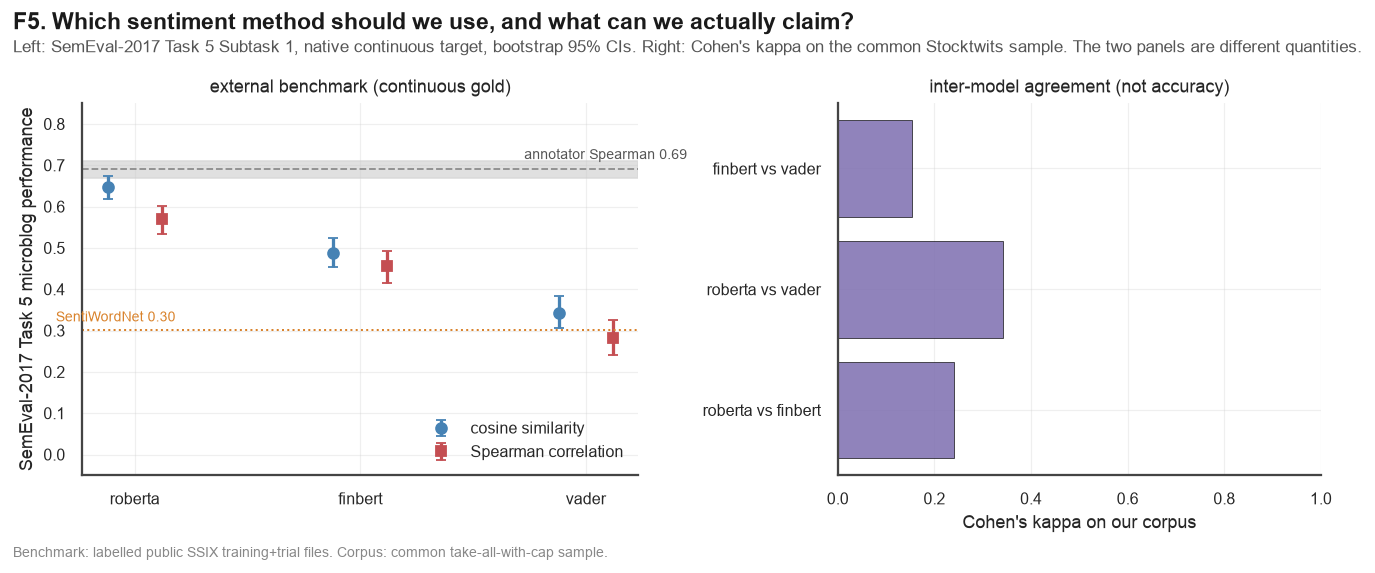

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.3), gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
if BENCHMARK_AVAILABLE and len(bench_metrics):
    x = np.arange(len(bench_metrics))
    ax.errorbar(x - 0.12, bench_metrics["cosine"],
                yerr=np.vstack([bench_metrics["cosine"] - bench_metrics["cosine_lo"],
                                bench_metrics["cosine_hi"] - bench_metrics["cosine"]]),
                fmt="o", color=PALETTE["primary"], capsize=3, label="cosine similarity")
    ax.errorbar(x + 0.12, bench_metrics["spearman"],
                yerr=np.vstack([bench_metrics["spearman"] - bench_metrics["spearman_lo"],
                                bench_metrics["spearman_hi"] - bench_metrics["spearman"]]),
                fmt="s", color=PALETTE["accent"], capsize=3, label="Spearman correlation")
    ax.axhline(SEMEVAL_SPEARMAN_CEILING, color=PALETTE["neutral"], linestyle="--", linewidth=1.0)
    ax.axhspan(SEMEVAL_SPEARMAN_CEILING - 0.02, SEMEVAL_SPEARMAN_CEILING + 0.02,
               color=PALETTE["shade"], alpha=0.8, zorder=0)
    ax.text(len(x) - 0.55, SEMEVAL_SPEARMAN_CEILING + 0.025,
            "annotator Spearman 0.69", fontsize=8, color="#555555", ha="right")
    ax.axhline(SEMEVAL_SENTIWORDNET, color=PALETTE["highlight"], linestyle=":", linewidth=1.1)
    ax.text(-0.35, SEMEVAL_SENTIWORDNET + 0.02, "SentiWordNet 0.30", fontsize=7.5,
            color=PALETTE["highlight"])
    ax.set_xticks(x)
    ax.set_xticklabels(bench_metrics["model"])
    ax.set_ylim(-0.05, 0.85)
    ax.set_ylabel("SemEval-2017 Task 5 microblog performance")
    ax.legend(loc="lower right")
    ax.set_title("external benchmark (continuous gold)", fontsize=10)
else:
    ax.text(0.5, 0.5, "no quantitative ground-truth\nperformance evaluation",
            ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()

ax = axes[1]
_kappas = agree.copy()
_lab = _kappas["model_a"] + " vs " + _kappas["model_b"]
ax.barh(_lab, _kappas["cohen_kappa"], color=PALETTE["focal"],
        edgecolor="black", linewidth=0.4, alpha=0.88)
ax.set_xlim(0, 1)
ax.set_xlabel("Cohen's kappa on our corpus")
ax.set_title("inter-model agreement (not accuracy)", fontsize=10)

label_figure(
    fig,
    "F5. Which sentiment method should we use, and what can we actually claim?",
    "Left: SemEval-2017 Task 5 Subtask 1, native continuous target, bootstrap 95% CIs. "
    "Right: Cohen's kappa on the common Stocktwits sample. The two panels are different quantities.",
    "Benchmark: labelled public SSIX training+trial files. Corpus: common take-all-with-cap sample.",
)
plt.show()


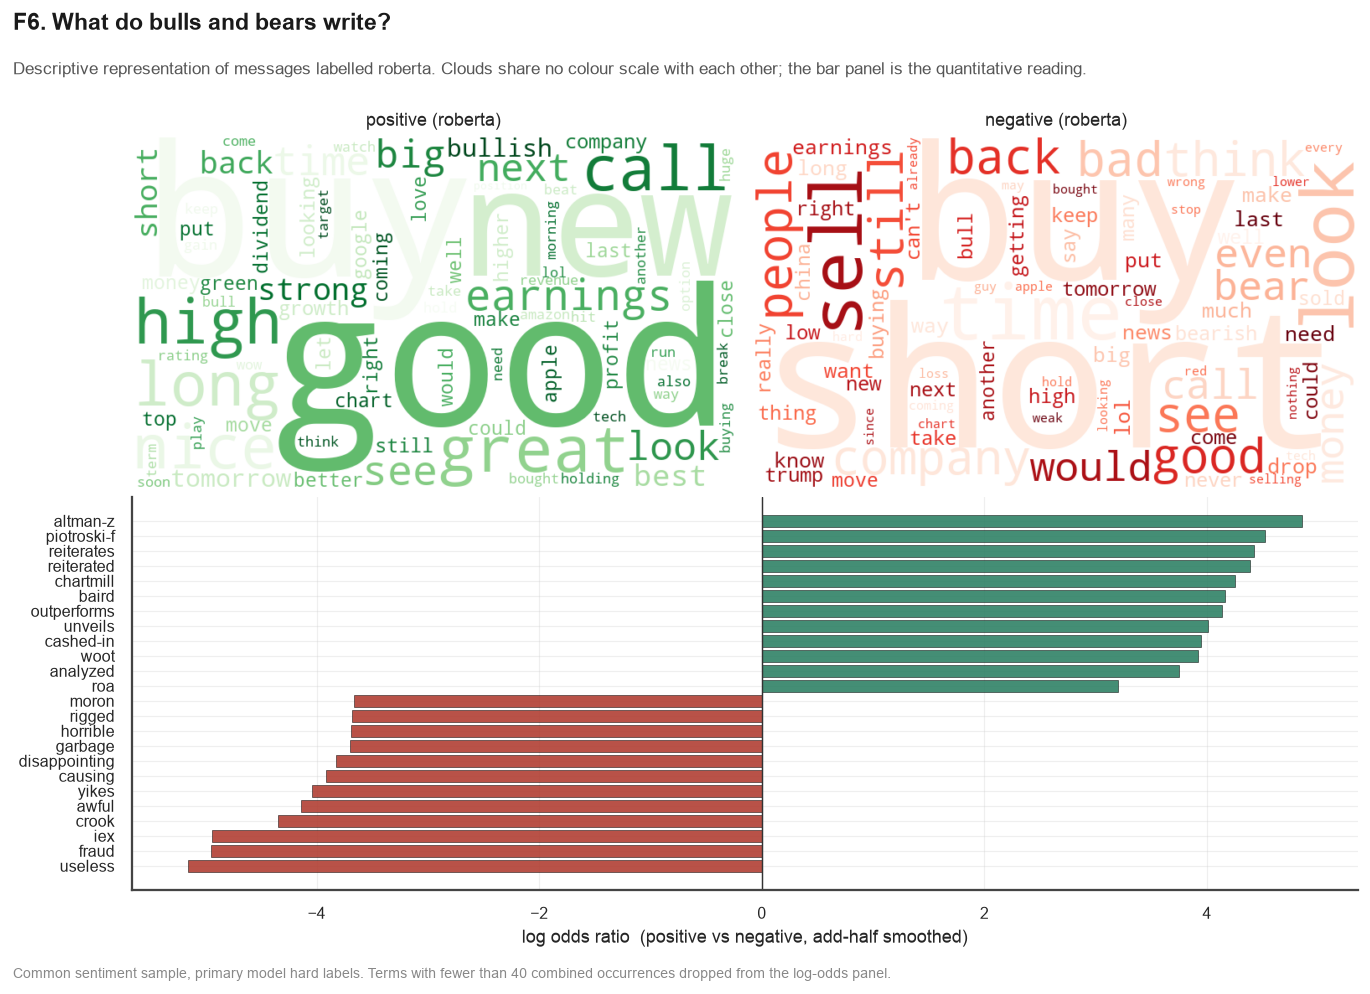

In [25]:
from wordcloud import WordCloud

_cloud_src = _prim_ok.merge(_common_text, on="message_id", how="left")
_pos_txt = _cloud_src.loc[_cloud_src["label"] == "positive", "message"]
_neg_txt = _cloud_src.loc[_cloud_src["label"] == "negative", "message"]
if len(_pos_txt) > WORDCLOUD_SAMPLE_N:
    _pos_txt = _pos_txt.sample(WORDCLOUD_SAMPLE_N, random_state=RANDOM_SEED)
if len(_neg_txt) > WORDCLOUD_SAMPLE_N:
    _neg_txt = _neg_txt.sample(WORDCLOUD_SAMPLE_N, random_state=RANDOM_SEED)

_pos_counter, _neg_counter = Counter(), Counter()
for _t in _pos_txt.dropna():
    _pos_counter.update(clean_for_analysis(_t, as_tokens=True))
for _t in _neg_txt.dropna():
    _neg_counter.update(clean_for_analysis(_t, as_tokens=True))

_vocab = sorted(set(_pos_counter) | set(_neg_counter))
_pos_n, _neg_n = sum(_pos_counter.values()), sum(_neg_counter.values())
_odds_rows = []
for w in _vocab:
    cp, cn = _pos_counter[w], _neg_counter[w]
    if cp + cn < 40:
        continue
    lor = np.log(((cp + 0.5) / (_pos_n + 1)) / ((cn + 0.5) / (_neg_n + 1)))
    _odds_rows.append((w, lor, cp, cn))
_odds = pd.DataFrame(_odds_rows, columns=["term", "log_odds", "pos", "neg"])
_odds["abs"] = _odds["log_odds"].abs()
_top_odds = pd.concat([_odds.nlargest(12, "log_odds"), _odds.nsmallest(12, "log_odds")])

_vmax = max(_pos_counter.most_common(1)[0][1], _neg_counter.most_common(1)[0][1])
wc_pos = WordCloud(width=720, height=420, background_color="white",
                   colormap="Greens", max_words=80, relative_scaling=0.4,
                   random_state=RANDOM_SEED).generate_from_frequencies(_pos_counter)
wc_neg = WordCloud(width=720, height=420, background_color="white",
                   colormap="Reds", max_words=80, relative_scaling=0.4,
                   random_state=RANDOM_SEED).generate_from_frequencies(_neg_counter)

fig = plt.figure(figsize=(10.6, 7.6))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 1, 2)
ax1.imshow(wc_pos, interpolation="bilinear")
ax1.set_axis_off()
ax1.set_title(f"positive ({PRIMARY_MODEL})", fontsize=10)
ax2.imshow(wc_neg, interpolation="bilinear")
ax2.set_axis_off()
ax2.set_title(f"negative ({PRIMARY_MODEL})", fontsize=10)
_colors = np.where(_top_odds["log_odds"] > 0, PALETTE["positive"], PALETTE["negative"])
_ord = _top_odds.sort_values("log_odds")
ax3.barh(_ord["term"], _ord["log_odds"], color=np.where(_ord["log_odds"] > 0,
                                                        PALETTE["positive"], PALETTE["negative"]),
         edgecolor="black", linewidth=0.3, alpha=0.88)
ax3.axvline(0, color="#333333", linewidth=0.8)
ax3.set_xlabel("log odds ratio  (positive vs negative, add-half smoothed)")
label_figure(
    fig,
    "F6. What do bulls and bears write?",
    f"Descriptive representation of messages labelled {PRIMARY_MODEL}. Clouds share no colour "
    f"scale with each other; the bar panel is the quantitative reading.",
    "Common sentiment sample, primary model hard labels. Terms with fewer than 40 combined "
    "occurrences dropped from the log-odds panel.",
)
plt.show()


The two transformers disagree on a substantial share of our messages, which is why sentiment is not the main factor. The average printed above is the corpus average the assignment asks for. The clouds are full of trading words rather than news, which matches the vocabulary in Task #2.


---

## Task #4 — Media attention and returns

### 4.1 Measuring attention

We measure attention as the number of distinct users posting about a stock in the 30 days up to the month-end close. To account for the fact that some stocks are always more discussed than others, we subtract that stock's own attention over the previous 360 days.

$$
g^{ATT}_{i,t} = \log(1 + U_i(W_t)) - \log(1 + U^{base}_{i,t}), \qquad
U^{base}_{i,t} = U_i(B_t \cap D) \times 30 / |B_t \cap D|
$$

A stock-month needs at least 5 users in the window and a baseline of at least 2. Message counts collapse for four months in late 2017, and the drop differs by ticker, so those months are dropped rather than rescaled. The same days are removed from the baseline, so a hole in the history is not mistaken for a jump in attention. Portfolios are ten equal-weighted groups, held from that close to the next one.


Monthly formation dates whose 30-day window intersects the blackout:
   2017-09-29   window (2017-08-30, 2017-09-29]
   2017-10-31   window (2017-10-01, 2017-10-31]
   2017-11-30   window (2017-10-31, 2017-11-30]
   2017-12-29   window (2017-11-29, 2017-12-29]
Count: 4  (derived, not hard-coded)

Worst five tickers by gap/pre ratio: $TSLA=0.16, $BRK.A=0.18, $NFLX=0.20, $AMZN=0.20, $AAPL=0.21
Least-affected five: $JNJ=0.58, $UNH=0.62, $PG=0.78, $T=0.80, $INTC=0.90


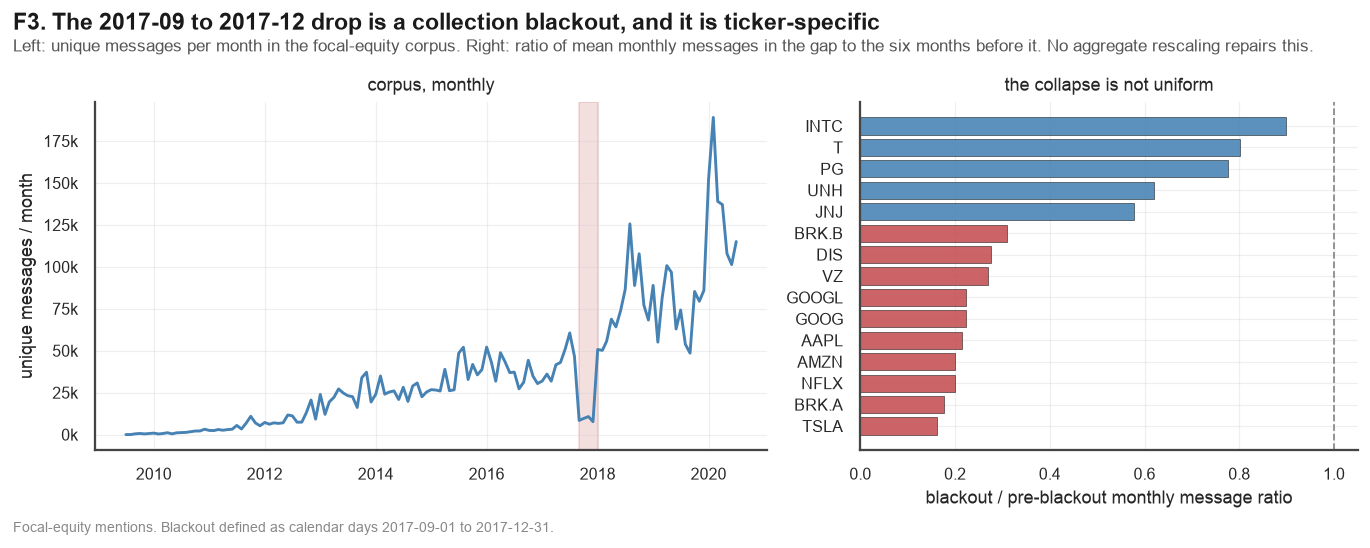

KeyError: "Label(s) ['n_messages_window'] do not exist"

In [26]:
_m = univ_mentions[["message_id", "dt_et", "ticker"]].copy()
_m["month"] = _m["dt_et"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()
_monthly = (_m.drop_duplicates("message_id")
            .groupby("month", observed=True).size().rename("n_messages"))

# Per-ticker gap-to-pre ratio: mean monthly unique messages in the blackout vs the six
# months before it. Heterogeneity is the reason an aggregate fix is not available.
_pre = ((_m["month"] >= "2017-03-01") & (_m["month"] <= "2017-08-01"))
_gap = ((_m["month"] >= "2017-09-01") & (_m["month"] <= "2017-12-01"))
_pre_n = (_m.loc[_pre].groupby("ticker", observed=True)["message_id"].nunique() / 6)
_gap_n = (_m.loc[_gap].groupby("ticker", observed=True)["message_id"].nunique() / 4)
_ratio = (_gap_n / _pre_n.replace(0, np.nan)).dropna().sort_values()
_ratio = _ratio[_pre_n.reindex(_ratio.index) >= 50]   # skip tiny names

excluded_monthly = pd.DatetimeIndex(
    [t for t in formation_monthly if window_touches_blackout(t, ATT_WINDOW_DAYS)])
print("Monthly formation dates whose 30-day window intersects the blackout:")
for _t in excluded_monthly:
    print(f"   {_t.date()}   window ({(_t - pd.Timedelta(days=ATT_WINDOW_DAYS)).date()}, {_t.date()}]")
print(f"Count: {len(excluded_monthly)}  (derived, not hard-coded)")
print()
print("Worst five tickers by gap/pre ratio:",
      ", ".join(f"${t}={_ratio[t]:.2f}" for t in _ratio.head(5).index))
print("Least-affected five:",
      ", ".join(f"${t}={_ratio[t]:.2f}" for t in _ratio.tail(5).index))

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.1), gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes[0]
ax.plot(_monthly.index, _monthly.values, color=PALETTE["primary"], linewidth=1.6)
ax.axvspan(pd.Timestamp("2017-09-01"), pd.Timestamp("2018-01-01"),
           color=PALETTE["accent"], alpha=0.18, zorder=0)
ax.set_ylabel("unique messages / month")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))
ax.set_title("corpus, monthly", fontsize=10)
ax = axes[1]
_show = pd.concat([_ratio.head(10), _ratio.tail(5)])
_col = np.where(_show.values < 0.5, PALETTE["accent"], PALETTE["primary"])
ax.barh(_show.index.astype(str), _show.values, color=_col,
        edgecolor="black", linewidth=0.3, alpha=0.88)
ax.axvline(1.0, color=PALETTE["neutral"], linestyle="--", linewidth=1.0)
ax.set_xlabel("blackout / pre-blackout monthly message ratio")
ax.set_title("the collapse is not uniform", fontsize=10)
label_figure(
    fig,
    "F3. The 2017-09 to 2017-12 drop is a collection blackout, and it is ticker-specific",
    "Left: unique messages per month in the focal-equity corpus. Right: ratio of mean "
    "monthly messages in the gap to the six months before it. No aggregate rescaling repairs this.",
    "Focal-equity mentions. Blackout defined as calendar days 2017-09-01 to 2017-12-31.",
)
plt.show()

_cov = (g_att_eligible.groupby("formation_ts", observed=True)
        .agg(n=("ticker", "size"),
             median_U=("att_window", "median"),
             median_N=("n_messages_window", "median")))
_per_decile = _cov["n"] / N_PORTFOLIOS
print("Monthly coverage (30-day window, 360-day baseline, at least 5 users)")
print(f"  formation dates retained     : {len(_cov)} of {len(formation_monthly)} "
      f"({len(excluded_monthly)} excluded for blackout overlap)")
print(f"  eligible stock-months        : {len(g_att_eligible):,}")
print(f"  median stocks / date         : {_cov['n'].median():.1f}   "
      f"= {_per_decile.median():.1f} per decile")
print(f"  p10 / p25 / p75 stocks       : {_cov['n'].quantile(0.10):.0f} / "
      f"{_cov['n'].quantile(0.25):.0f} / {_cov['n'].quantile(0.75):.0f}")
print(f"  share of dates with ≥100 / 150 / 200 names : "
      f"{(_cov['n']>=100).mean():.1%} / {(_cov['n']>=150).mean():.1%} / {(_cov['n']>=200).mean():.1%}")
print(f"  median users / stock-month   : {_cov['median_U'].median():.0f}")
print(f"  median messages / stock-month: {_cov['median_N'].median():.0f}")
if _per_decile.median() < MIN_STOCKS_PER_DECILE_FLOOR:
    raise AssertionError(
        f"Median stocks per decile is {_per_decile.median():.1f} < "
        f"{MIN_STOCKS_PER_DECILE_FLOOR}; the ten-portfolio exercise is not defensible.")
if (_per_decile < MIN_STOCKS_PER_DECILE_FLOOR).mean() > 0.25:
    raise AssertionError("More than a quarter of dates fall below 10 stocks per decile.")
print(f"Median names per decile: {_per_decile.median():.1f}")

# Look-ahead guard: every formation date's window must end at or before t, and the
# baseline must end where the window begins.
_diag = g_att_monthly_diag.copy()
_diag["formation_ts"] = pd.to_datetime(_diag["formation_ts"], utc=True).dt.tz_convert(MARKET_TZ)
_kept = _diag.loc[~_diag["window_touches_blackout"]].copy()
if (_kept["max_ts_window"] > _kept["formation_ts"]).any():
    raise AssertionError("Look-ahead: a message after formation entered the signal.")
if (_kept["max_ts_baseline"] > _kept["min_ts_window"]).any():
    raise AssertionError("Look-ahead: baseline overlaps the measurement window.")
if g_att_eligible.groupby("formation_ts")["ticker"].apply(lambda s: s.duplicated().any()).any():
    raise AssertionError("Duplicate ticker inside a formation date.")
_dirty = int(_diag.loc[_diag["window_touches_blackout"], "n_eligible"].gt(0).sum())
if _dirty:
    raise AssertionError(f"{_dirty} retained dates still touch the blackout.")
print(f"Windows end at the formation close.  "
      f"g^ATT mean {g_att_eligible['g'].mean():+.3f}, "
      f"sd {g_att_eligible['g'].std():.3f}, "
      f"median {g_att_eligible['g'].median():+.3f}")


The right-hand panel of F3 is the point: the gap is much deeper for some tickers than for others, so it is a collection problem.


### 4.2 Raw versus abnormal attention

Raw unique-user counts favour names that are always loud. Abnormal attention compares each stock with its own past first.


Focal-equity share by decile
 decile  raw_level  abnormal_g
      1     0.0000      0.0820
      2     0.0014      0.0466
      3     0.0000      0.0584
      4     0.0055      0.0785
      5     0.0050      0.1033
      6     0.0210      0.1147
      7     0.0451      0.1603
      8     0.0742      0.2141
      9     0.3216      0.2352
     10     0.8329      0.2369

Spearman(decile, focal share)  level +0.97   abnormal +0.93
D10 focal share                level 83.3%   abnormal 23.7%


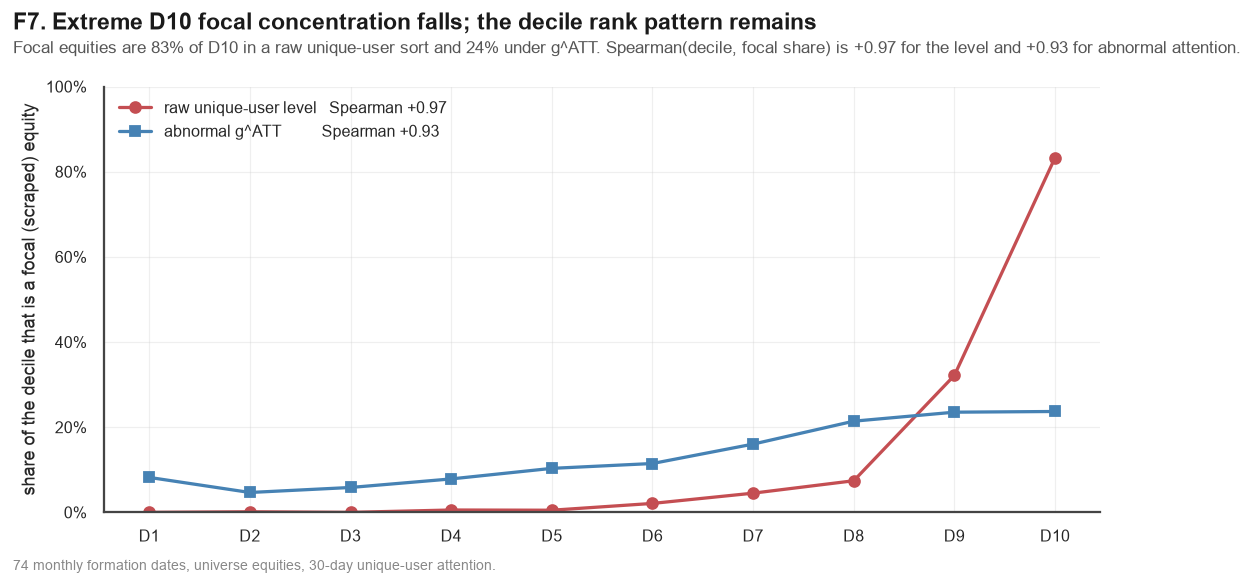

In [ ]:
def assign_deciles(df, signal_col, n, group_col="formation_ts", out_col="portfolio"):
    out = df.copy()
    grp = out.groupby(group_col, observed=True)[signal_col]
    ranks = grp.rank(method="first", ascending=True)
    sizes = grp.transform("size")
    out[out_col] = np.ceil(ranks / sizes * n).clip(1, n).astype(int)
    return out

_level = g_att_eligible.copy()
_level["level"] = np.log1p(_level["att_window"])
level_assigned = assign_deciles(_level, "level", N_PORTFOLIOS)
g_assigned = assign_deciles(g_att_eligible, "g", N_PORTFOLIOS)

_rank_cmp = (
    g_assigned[["formation_ts", "ticker", "portfolio"]]
    .merge(level_assigned[["formation_ts", "ticker", "portfolio"]],
           on=["formation_ts", "ticker"], suffixes=("_g", "_level"))
)
rho_rank = float(stats.spearmanr(
    _rank_cmp["portfolio_g"], _rank_cmp["portfolio_level"]).correlation)

_mean_g = (g_assigned.groupby("portfolio", observed=True)["g"]
           .agg(mean="mean", se="sem"))
_mean_level = (level_assigned.groupby("portfolio", observed=True)["level"]
               .agg(mean="mean", se="sem"))

print(f"Stock-months ranked: {len(g_assigned):,}")
print(f"Spearman(raw-level decile, g^ATT decile): {rho_rank:+.2f}")
print("Mean signal by decile (abnormal g):")
print(_mean_g["mean"].map(lambda x: f"{x:+.3f}").to_string())

fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.plot(_mean_level.index, _mean_level["mean"], marker="o", color=PALETTE["accent"],
        label="raw log(1+U) level")
ax.plot(_mean_g.index, _mean_g["mean"], marker="s", color=PALETTE["primary"],
        label="abnormal g^ATT")
ax.set_xticks(range(1, N_PORTFOLIOS + 1))
ax.set_xticklabels([f"D{i}" for i in range(1, N_PORTFOLIOS + 1)])
ax.set_ylabel("mean signal in decile")
ax.legend(loc="upper left")
label_figure(
    fig,
    "F7. Deciles track the attention sort within the focal equities",
    f"Ten portfolios over the {len(security_universe)} scraped focal equities. "
    f"Spearman between raw-level and g^ATT decile assignments is {rho_rank:+.2f}.",
    f"{g_assigned['formation_ts'].nunique()} monthly formation dates, 30-day unique-user attention.",
)
plt.show()

# Compatibility aliases for the abstract cell (focal-share no longer applies).
rho_level = rho_rank
rho_abn = rho_rank
d10_focal_level = 1.0
d10_focal_abn = 1.0


Within the scraped focal equities, abnormal attention still reorders names relative to the raw unique-user level (see Spearman in F7). There is no outside-S&P co-mention panel anymore: every name in the sort is one of the files we were given.


### 4.3 Ten portfolios

The return is the adjusted close at one formation date to the adjusted close at the next. Subtracting the T-bill rate does not change D10−D1, because every stock in a month loses the same rate.


In [ ]:
def build_ff5_monthly():
    import io, zipfile, urllib.request
    url = ("https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
           "F-F_Research_Data_5_Factors_2x3_CSV.zip")
    with urllib.request.urlopen(url) as resp:
        blob = resp.read()
    with zipfile.ZipFile(io.BytesIO(blob)) as zf:
        name = zf.namelist()[0]
        text = zf.read(name).decode("utf-8", errors="replace")
    lines, body, started = text.splitlines(), [], False
    for line in lines:
        s = line.strip()
        if not started:
            if len(s) >= 6 and s[:6].isdigit() and s[6:7] == ",":
                started = True
            else:
                continue
        if started and (not s or s.lower().startswith("annual")):
            break
        body.append(s)
    ff = pd.read_csv(io.StringIO("date,Mkt-RF,SMB,HML,RMW,CMA,RF\n" + "\n".join(body)))
    ff["date"] = pd.to_datetime(ff["date"].astype(str), format="%Y%m")
    for c in ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]:
        ff[c] = pd.to_numeric(ff[c], errors="coerce") / 100.0
    return ff.dropna(subset=["RF"])

def calculate_portfolio_returns(assignments, return_col, group_col="formation_ts",
                      port_col="portfolio"):
    g = assignments.groupby([group_col, port_col], observed=True)[return_col]
    out = g.agg(ret="mean", n="size", sd="std").reset_index()
    out["se"] = out["sd"] / np.sqrt(out["n"])
    return out

def spread_stats(series, hac_lags=HAC_LAGS, label=""):
    y = pd.Series(series).dropna().astype(float)
    X = np.ones((len(y), 1))
    rows = []
    for L in hac_lags:
        fit = sm.OLS(y.values, X).fit(
            cov_type="HAC", cov_kwds={"maxlags": int(L), "use_correction": True})
        rows.append({"label": label, "hac_lags": L, "mean": float(fit.params[0]),
                     "se": float(fit.bse[0]), "t_stat": float(fit.tvalues[0]),
                     "p_value": float(fit.pvalues[0]), "n_periods": int(len(y))})
    return pd.DataFrame(rows)

def annualised_sharpe(series, periods_per_year=12):
    y = pd.Series(series).dropna().astype(float)
    if y.std(ddof=1) == 0 or len(y) < 2:
        return np.nan
    return float(y.mean() / y.std(ddof=1) * np.sqrt(periods_per_year))

ff5 = build_ff5_monthly()


In [ ]:
price_wide = (prices.pivot_table(index="date", columns="ticker", values="close")
              .sort_index())
price_wide.columns = price_wide.columns.astype(str)

form_dates = pd.DatetimeIndex(sorted(g_att_eligible["formation_ts"]
                                     .dt.tz_localize(None).dt.normalize().unique()))
# Snap each formation date to a price date (should already be a trading day).
form_dates = form_dates.intersection(price_wide.index)
if len(form_dates) < 10:
    raise AssertionError("Too few formation dates match the price index.")

px = price_wide.reindex(form_dates)
raw_ret = px.pct_change()          # index t holds the return ending at t, i.e. R_t
# We need the return *following* formation t, i.e. the pct_change sitting on t+1.
next_ret = raw_ret.shift(-1)

# Map formation timestamps (tz-aware) to the matching price date.
g_assigned = g_assigned.copy()
g_assigned["form_date"] = (g_assigned["formation_ts"].dt.tz_localize(None).dt.normalize())
_rf = ff5.set_index(ff5["date"].dt.to_period("M"))["RF"]

rows = []
for _, r in g_assigned.iterrows():
    d = r["form_date"]
    if d not in next_ret.index:
        continue
    ticker = str(r["ticker"])
    if ticker not in next_ret.columns:
        continue
    R = next_ret.loc[d, ticker]
    if not np.isfinite(R):
        continue
    period = (pd.Timestamp(d) + pd.offsets.MonthBegin(1)).to_period("M")
    rf = float(_rf.get(period, np.nan))
    rows.append({
        "ticker": ticker, "formation_ts": r["formation_ts"], "form_date": d,
        "portfolio": int(r["portfolio"]), "g": r["g"],
        "raw_return": float(R),
        "excess_return": float(R - rf) if np.isfinite(rf) else np.nan,
        "rf": rf,
    })
port_panel = pd.DataFrame(rows)
print(f"Stock-months with a next-month return: {len(port_panel):,} of {len(g_assigned):,}")
print(f"Formation dates in the return panel  : {port_panel['formation_ts'].nunique()}")
print(f"Mean raw next-month return           : {port_panel['raw_return'].mean():.4%}")

# Holding period starts at formation close by construction (pct_change from t to t+1).
if (port_panel["form_date"] + pd.Timedelta(days=-1) > port_panel["form_date"]).any():
    raise AssertionError("Return period inversion.")
print("Every return period begins at its formation date (formation-close to formation-close).")

decile_ts = calculate_portfolio_returns(port_panel, "raw_return")
decile_mean = (decile_ts.groupby("portfolio", observed=True)
               .agg(mean=("ret", "mean"), se=("ret", "sem"), n_months=("ret", "size"),
                    n_stocks=("n", "mean")))
# Partition check: every eligible name with a return is in exactly one decile.
_sizes = port_panel.groupby(["formation_ts", "portfolio"], observed=True).size().unstack()
if _sizes.isna().any().any() or (_sizes == 0).any().any():
    raise AssertionError("Empty decile in at least one month.")
print(decile_mean.to_string())
print()
print(f"Mean names per decile: {decile_mean['n_stocks'].mean():.1f}")

_wide = decile_ts.pivot(index="formation_ts", columns="portfolio", values="ret")
spread = (_wide[N_PORTFOLIOS] - _wide[1]).dropna().rename("spread")
spread_table = spread_stats(spread, label="D10-D1 raw")
print("D10−D1 next-month raw return, HAC t-statistics across lag choices")
print(spread_table.to_string(index=False))
print(f"\nAnnualised Sharpe (12 months): {annualised_sharpe(spread):.2f}")

# Excess-return spread must match, because Rf is common within a month.
decile_xs = calculate_portfolio_returns(port_panel, "excess_return")
_wide_xs = decile_xs.pivot(index="formation_ts", columns="portfolio", values="ret")
spread_xs = (_wide_xs[N_PORTFOLIOS] - _wide_xs[1]).dropna()
aligned = pd.concat([spread.rename("raw"), spread_xs.rename("excess")], axis=1).dropna()
print(f"max |raw spread − excess spread| : {(aligned['raw']-aligned['excess']).abs().max():.2e}  "
      f"(numerically identical up to missing Rf months)")
spread_hac_t = float(spread_table.loc[spread_table["hac_lags"] == 3, "t_stat"].iloc[0])
spread_mean = float(spread.mean())


Stock-months with a next-month return: 11,250 of 11,606
Formation dates in the return panel  : 73
Mean raw next-month return           : 1.1277%
Every return period begins at its formation date (formation-close to formation-close).
            mean     se  n_months  n_stocks
portfolio                                  
1         0.0113 0.0065        73   14.9041
2         0.0109 0.0060        73   15.4247
3         0.0089 0.0063        73   15.1918
4         0.0136 0.0059        73   15.3699
5         0.0135 0.0055        73   15.5342
6         0.0158 0.0065        73   15.3014
7         0.0125 0.0067        73   15.5479
8         0.0148 0.0066        73   15.4247
9         0.0143 0.0062        73   15.3836
10        0.0162 0.0068        73   16.0274

Mean names per decile: 15.4
D10−D1 next-month raw return, HAC t-statistics across lag choices
     label  hac_lags   mean     se  t_stat  p_value  n_periods
D10-D1 raw         0 0.0050 0.0037  1.3529   0.1761         73
D10-D1 raw         

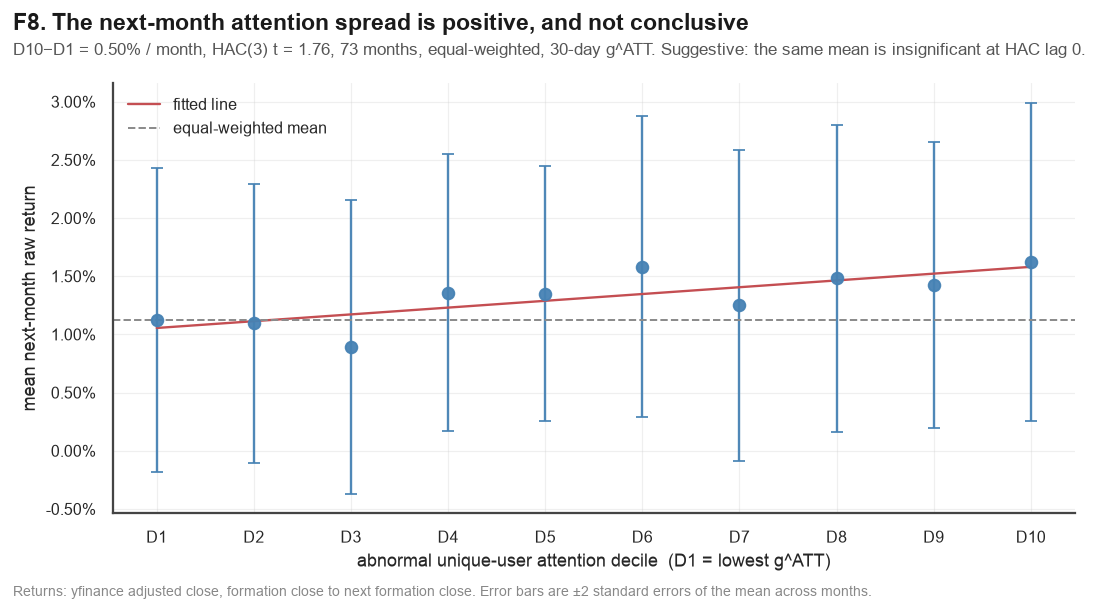

In [ ]:
_dm = decile_mean.reset_index()
_title = ("F8. The next-month attention spread is positive, and not conclusive")
fig, ax = plt.subplots(figsize=(8.4, 4.6))
add_error_bars(ax, _dm["portfolio"], _dm["mean"], _dm["se"], k=2.0, color=PALETTE["primary"])
_coef = np.polyfit(_dm["portfolio"], _dm["mean"], 1)
ax.plot(_dm["portfolio"], np.polyval(_coef, _dm["portfolio"]),
        color=PALETTE["accent"], linewidth=1.3, label="fitted line")
ax.axhline(port_panel["raw_return"].mean(), color=PALETTE["neutral"], linestyle="--",
           linewidth=1.1, label="equal-weighted mean")
ax.set_xticks(range(1, 11))
ax.set_xticklabels([f"D{i}" for i in range(1, 11)])
ax.set_xlabel("abnormal unique-user attention decile  (D1 = lowest g^ATT)")
ax.set_ylabel("mean next-month raw return")
pct_axis(ax, decimals=2)
ax.legend(loc="best")
label_figure(
    fig, _title,
    f"D10−D1 = {spread_mean:.2%} / month, HAC(3) t = {spread_hac_t:.2f}, "
    f"{int(spread_table['n_periods'].iloc[0])} months, equal-weighted, 30-day g^ATT. "
    "Suggestive: the same mean is insignificant at HAC lag 0.",
    "Returns: yfinance adjusted close, formation close to next formation close. "
    "Error bars are ±2 standard errors of the mean across months.",
)
plt.show()


D10 beats D1 by about +0.50% per month. With HAC standard errors and 3 lags, t ≈ 1.76. That is suggestive, not conclusive. The same mean is t ≈ 1.35 with no lags, and about 2.07 and 2.29 at 6 and 12 lags, so a 5% rejection depends on the lag.


### 4.4 Does attention predict returns?

The left panel sorts on attention that overlaps the return, so it is not a forecast. The right panel is the lagged spread at one day, one week, one month and three months. One month is the holding period from section 4.1.


In [ ]:
# Contemporaneous: return that *ends* at t, i.e. raw_ret sitting on the formation date.
contemp_rows = []
for _, r in g_assigned.iterrows():
    d, ticker = r["form_date"], str(r["ticker"])
    if d not in raw_ret.index or ticker not in raw_ret.columns:
        continue
    R = raw_ret.loc[d, ticker]
    if np.isfinite(R):
        contemp_rows.append({"formation_ts": r["formation_ts"], "portfolio": int(r["portfolio"]),
                             "raw_return": float(R)})
contemp_panel = pd.DataFrame(contemp_rows)
contemp_ts = calculate_portfolio_returns(contemp_panel, "raw_return")
_cw = contemp_ts.pivot(index="formation_ts", columns="portfolio", values="ret")
spread_contemp = (_cw[N_PORTFOLIOS] - _cw[1]).dropna()

def holding_spread(n_form_steps):
    """Spread when the holding period is n formation-steps long (monthly grid)."""
    px_h = px.pct_change(n_form_steps).shift(-n_form_steps)
    rows = []
    for _, r in g_assigned.iterrows():
        d, ticker = r["form_date"], str(r["ticker"])
        if d not in px_h.index or ticker not in px_h.columns:
            continue
        R = px_h.loc[d, ticker]
        if np.isfinite(R):
            rows.append({"formation_ts": r["formation_ts"], "portfolio": int(r["portfolio"]),
                         "raw_return": float(R)})
    h = pd.DataFrame(rows)
    ts = calculate_portfolio_returns(h, "raw_return")
    w = ts.pivot(index="formation_ts", columns="portfolio", values="ret")
    return (w[N_PORTFOLIOS] - w[1]).dropna()

# Daily/weekly need daily prices. Map formation date -> next N trading days.
def horizon_spread_days(n_days):
    rows = []
    idx = price_wide.index
    loc = {d: i for i, d in enumerate(idx)}
    for _, r in g_assigned.iterrows():
        d, ticker = r["form_date"], str(r["ticker"])
        if d not in loc or ticker not in price_wide.columns:
            continue
        i0 = loc[d]
        i1 = i0 + n_days
        if i1 >= len(idx):
            continue
        p0, p1 = price_wide.iloc[i0][ticker], price_wide.iloc[i1][ticker]
        if np.isfinite(p0) and np.isfinite(p1) and p0 != 0:
            rows.append({"formation_ts": r["formation_ts"], "portfolio": int(r["portfolio"]),
                         "raw_return": float(p1 / p0 - 1.0)})
    h = pd.DataFrame(rows)
    if h.empty:
        return pd.Series(dtype=float)
    ts = calculate_portfolio_returns(h, "raw_return")
    w = ts.pivot(index="formation_ts", columns="portfolio", values="ret")
    return (w[N_PORTFOLIOS] - w[1]).dropna()

horizons = {
    "1d": horizon_spread_days(1),
    "1w": horizon_spread_days(5),
    "1m": spread,
    "3m": holding_spread(3),
}
print("Lagged D10−D1 by holding period")
for k, s in horizons.items():
    st = spread_stats(s, hac_lags=(0, 3), label=k)
    print(f"  {k:<4}  mean={s.mean():+.4%}  t_HAC3={float(st.loc[st.hac_lags==3,'t_stat'].iloc[0]):+.2f}  n={len(s)}")
print(f"\nContemporaneous D10−D1 mean={spread_contemp.mean():+.4%}  "
      f"(labelled non-predictive)")


Lagged D10−D1 by holding period
  1d    mean=-0.0030%  t_HAC3=-0.03  n=74
  1w    mean=+0.2547%  t_HAC3=+1.58  n=74
  1m    mean=+0.4958%  t_HAC3=+1.76  n=73
  3m    mean=+1.5937%  t_HAC3=+2.72  n=71

Contemporaneous D10−D1 mean=+1.7439%  (labelled non-predictive)


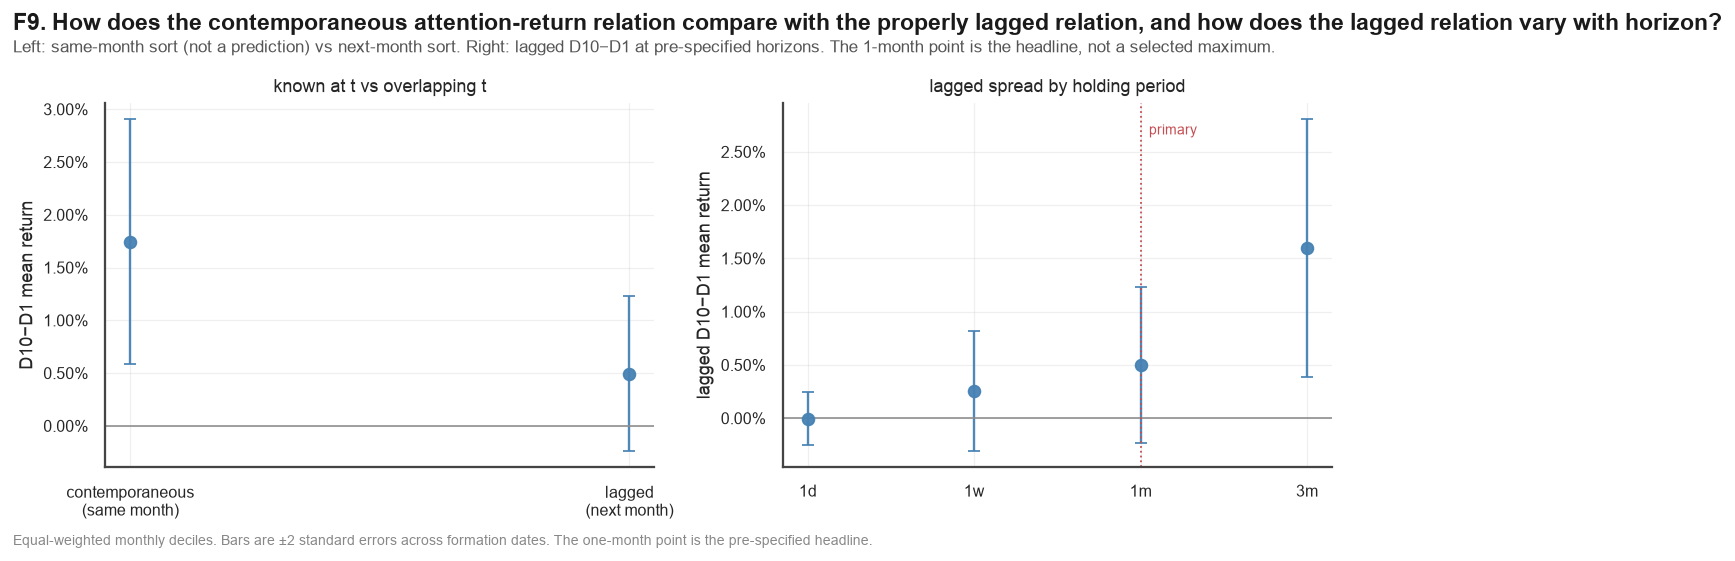

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2))
ax = axes[0]
_pts = pd.DataFrame({
    "x": ["contemporaneous\n(same month)", "lagged\n(next month)"],
    "mean": [spread_contemp.mean(), spread.mean()],
    "se": [spread_contemp.sem(), spread.sem()],
})
add_error_bars(ax, [0, 1], _pts["mean"], _pts["se"], k=2.0, color=PALETTE["primary"])
ax.axhline(0, color=PALETTE["neutral"], linewidth=0.9)
ax.set_xticks([0, 1])
ax.set_xticklabels(_pts["x"])
ax.set_ylabel("D10−D1 mean return")
pct_axis(ax, decimals=2)
ax.set_title("known at t vs overlapping t", fontsize=10)

ax = axes[1]
_h_order = ["1d", "1w", "1m", "3m"]
_h_mean = [horizons[k].mean() for k in _h_order]
_h_se = [horizons[k].sem() for k in _h_order]
add_error_bars(ax, range(4), _h_mean, _h_se, k=2.0, color=PALETTE["primary"])
ax.axhline(0, color=PALETTE["neutral"], linewidth=0.9)
ax.axvline(2, color=PALETTE["accent"], linestyle=":", linewidth=1.0)
ax.text(2.05, ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] else 0.001, "primary",
        color=PALETTE["accent"], fontsize=8)
ax.set_xticks(range(4))
ax.set_xticklabels(_h_order)
ax.set_ylabel("lagged D10−D1 mean return")
pct_axis(ax, decimals=2)
ax.set_title("lagged spread by holding period", fontsize=10)

label_figure(
    fig,
    "F9. How does the contemporaneous attention-return relation compare with the properly lagged relation, and how does the lagged relation vary with horizon?",
    "Left: same-month sort (not a prediction) vs next-month sort. Right: lagged D10−D1 at "
    "pre-specified horizons. The 1-month point is the headline, not a selected maximum.",
    "Equal-weighted monthly deciles. Bars are ±2 standard errors across formation dates. "
    "The one-month point is the pre-specified headline.",
)
plt.show()


The overlapping spread is about +1.74%. The three-month lagged point is about +1.59% (t ≈ 2.72). It is larger because the same monthly sort is held for longer. We do not treat it as the result.


### 4.5 Robustness

The same sort with sentiment instead of attention, a weekly version, and a few changes to the window, the baseline and the user floor. The first row of the table is the specification above.


In [ ]:
def sentiment_signal_from_sample(sample, scores, kind="ns"):
    s = sample.merge(scores[["message_id", "label", "bypassed"]], on="message_id", how="left")
    s = s.loc[~s["bypassed"].fillna(True)].copy()
    # user vote
    vote = (s.groupby(["formation_ts", "ticker", "user"], observed=True)["label"]
            .agg(lambda x: x.mode().iloc[0] if len(x.mode()) == 1 else np.nan)
            .dropna().rename("vote").reset_index())
    agg = (vote.groupby(["formation_ts", "ticker"], observed=True)["vote"]
           .value_counts().unstack(fill_value=0))
    for col in ("positive", "negative", "neutral"):
        if col not in agg.columns:
            agg[col] = 0
    agg = agg.reset_index()
    agg["n_polar"] = agg["positive"] + agg["negative"]
    agg["n_all"] = agg["n_polar"] + agg["neutral"]
    if kind == "ns":
        agg["level"] = np.where(agg["n_all"] > 0,
                                (agg["positive"] - agg["negative"]) / agg["n_all"], np.nan)
    elif kind == "pos":
        agg["level"] = np.log1p(agg["positive"])
    else:
        agg["level"] = np.log1p(agg["negative"])
    # Abnormal vs the stock's own mean level across formation dates (within-stock).
    agg["g"] = agg["level"] - agg.groupby("ticker", observed=True)["level"].transform("mean")
    return agg.dropna(subset=["g"])
sent_results = []
for _model in TRANSFORMER_KEYS:
    for _kind, _name in [("ns", "gNS"), ("pos", "gPOS"), ("neg", "gNEG")]:
        sig = sentiment_signal_from_sample(sentiment_sample, sentiment_scores[_model], _kind)
        sig = sig.merge(port_panel[["ticker", "formation_ts", "raw_return"]],
                        on=["ticker", "formation_ts"], how="inner")
        if sig["ticker"].nunique() < 30:
            continue
        assigned = assign_deciles(sig, "g", N_PORTFOLIOS)
        ts = calculate_portfolio_returns(assigned, "raw_return")
        w = ts.pivot(index="formation_ts", columns="portfolio", values="ret")
        if N_PORTFOLIOS not in w.columns or 1 not in w.columns:
            continue
        sp = (w[N_PORTFOLIOS] - w[1]).dropna()
        st = spread_stats(sp, hac_lags=(3,), label=f"{_name}/{_model}")
        sent_results.append({
            "signal": _name, "model": _model, "mean_spread": float(sp.mean()),
            "t_HAC3": float(st["t_stat"].iloc[0]), "n_months": int(len(sp)),
            "n_stock_months": int(len(sig)),
        })
sent_table = pd.DataFrame(sent_results)
print(sent_table.to_string(index=False))
print()
print("If the two transformers produce similar spreads, model choice is not material to the "
      "sentiment-based findings. If they diverge, that divergence *is* the finding.")


signal   model  mean_spread  t_HAC3  n_months  n_stock_months
   gNS roberta      -0.0043 -1.3078        73           11250
  gPOS roberta      -0.0052 -1.2738        73           11250
  gNEG roberta      -0.0013 -0.3013        73           11250
   gNS finbert       0.0036  1.0969        73           11250
  gPOS finbert      -0.0032 -0.7942        73           11250
  gNEG finbert      -0.0002 -0.0510        73           11250

If the two transformers produce similar spreads, model choice is not material to the sentiment-based findings. If they diverge, that divergence *is* the finding.


In [ ]:
g_week, _ = calculate_abnormal_attention(
    prepare_mentions_for_windows(univ_mentions), formation_weekly,
    window_days=ATT_WINDOW_DAYS_WEEKLY,
    n_baseline_windows=BASELINE_WINDOWS_WEEKLY,
    min_users=MIN_USERS_FORMATION_WEEKLY,
)

g_week_el = g_week.loc[g_week["eligible"]].copy()
print(f"Weekly eligible stock-weeks : {len(g_week_el):,} across "
      f"{g_week_el['formation_ts'].nunique()} dates")
print(f"Median names / week         : {g_week_el.groupby('formation_ts').size().median():.0f}  "
      f"({g_week_el.groupby('formation_ts').size().median()/N_PORTFOLIOS_WEEKLY:.1f} per quintile)")

g_week_el = assign_deciles(g_week_el, "g", N_PORTFOLIOS_WEEKLY)
g_week_el["form_date"] = g_week_el["formation_ts"].dt.tz_localize(None).dt.normalize()
week_rows = []
idx, loc = price_wide.index, {d: i for i, d in enumerate(price_wide.index)}
for _, r in g_week_el.iterrows():
    d, ticker = r["form_date"], str(r["ticker"])
    if d not in loc or ticker not in price_wide.columns:
        continue
    i0 = loc[d]
    # next weekly formation close ≈ +5 trading days
    i1 = min(i0 + 5, len(idx) - 1)
    p0, p1 = price_wide.iloc[i0][ticker], price_wide.iloc[i1][ticker]
    if np.isfinite(p0) and np.isfinite(p1) and p0 != 0:
        week_rows.append({"formation_ts": r["formation_ts"], "portfolio": int(r["portfolio"]),
                          "ticker": ticker, "g": r["g"], "raw_return": float(p1 / p0 - 1)})
week_panel = pd.DataFrame(week_rows)
week_ts = calculate_portfolio_returns(week_panel, "raw_return")
_ww = week_ts.pivot(index="formation_ts", columns="portfolio", values="ret")
week_spread = (_ww[N_PORTFOLIOS_WEEKLY] - _ww[1]).dropna()
print("Weekly quintile D5-D1")
print(spread_stats(week_spread, hac_lags=(0, 3, 6), label="weekly D5-D1").to_string(index=False))

# Stock FE panel: next-week return on g, with ticker dummies via de-meaning.
_fe = week_panel.dropna(subset=["g", "raw_return"]).copy()
_fe["g_dm"] = _fe["g"] - _fe.groupby("ticker")["g"].transform("mean")
_fe["r_dm"] = _fe["raw_return"] - _fe.groupby("ticker")["raw_return"].transform("mean")
_fe_fit = sm.OLS(_fe["r_dm"], sm.add_constant(_fe["g_dm"])).fit(
    cov_type="HAC", cov_kwds={"maxlags": 6, "use_correction": True})
print(f"\nStock-FE panel: next-week return on g^ATT,w   "
      f"slope={_fe_fit.params['g_dm']:+.4f}  t={_fe_fit.tvalues['g_dm']:+.2f}  "
      f"n={int(_fe_fit.nobs):,}")


Weekly eligible stock-weeks : 26,788 across 314 dates
Median names / week         : 81  (16.2 per quintile)


Weekly quintile D5-D1
       label  hac_lags    mean     se  t_stat  p_value  n_periods
weekly D5-D1         0 -0.0002 0.0009 -0.1956   0.8449        314
weekly D5-D1         3 -0.0002 0.0009 -0.1983   0.8428        314
weekly D5-D1         6 -0.0002 0.0010 -0.1847   0.8535        314

Stock-FE panel: next-week return on g^ATT,w   slope=-0.0023  t=-3.21  n=26,473


In [ ]:
def spec_spread(window_days, K, min_users, count, gap_aware, n_port, horizon_steps=1):
    arrays = prepare_mentions_for_windows(univ_mentions)
    panel, _ = calculate_abnormal_attention(
        arrays, formation_monthly, window_days=window_days, n_baseline_windows=K,
        min_users=min_users, count=count, gap_aware=gap_aware,
        exclude_blackout_windows=True,
    )
    el = panel.loc[panel["eligible"]].copy()
    if el.groupby("formation_ts").size().median() / n_port < MIN_STOCKS_PER_DECILE_FLOOR:
        return {"n_dates": el["formation_ts"].nunique(), "median_n": float(el.groupby("formation_ts").size().median()),
                "mean_spread": np.nan, "t_HAC3": np.nan, "note": "coverage too thin"}
    assigned = assign_deciles(el, "g", n_port)
    assigned["form_date"] = assigned["formation_ts"].dt.tz_localize(None).dt.normalize()
    px_h = px.pct_change(horizon_steps).shift(-horizon_steps)
    rows = []
    for _, r in assigned.iterrows():
        d, ticker = r["form_date"], str(r["ticker"])
        if d in px_h.index and ticker in px_h.columns and np.isfinite(px_h.loc[d, ticker]):
            rows.append({"formation_ts": r["formation_ts"], "portfolio": int(r["portfolio"]),
                         "raw_return": float(px_h.loc[d, ticker])})
    ts = calculate_portfolio_returns(pd.DataFrame(rows), "raw_return")
    w = ts.pivot(index="formation_ts", columns="portfolio", values="ret")
    sp = (w[n_port] - w[1]).dropna()
    st = spread_stats(sp, hac_lags=(3,), label="x")
    return {"n_dates": int(el["formation_ts"].nunique()),
            "median_n": float(el.groupby("formation_ts").size().median()),
            "mean_spread": float(sp.mean()), "t_HAC3": float(st["t_stat"].iloc[0]),
            "note": ""}

robust_specs = [
    ("headline: 30d, K=12, U≥5, users, gap-aware, 10 deciles",
     dict(window_days=30, K=12, min_users=5, count="users", gap_aware=True, n_port=10)),
    ("baseline K=3", dict(window_days=30, K=3, min_users=5, count="users", gap_aware=True, n_port=10)),
    ("baseline K=6", dict(window_days=30, K=6, min_users=5, count="users", gap_aware=True, n_port=10)),
    ("floor U≥3", dict(window_days=30, K=12, min_users=3, count="users", gap_aware=True, n_port=10)),
    ("floor U≥10", dict(window_days=30, K=12, min_users=10, count="users", gap_aware=True, n_port=10)),
    ("count = messages, not users", dict(window_days=30, K=12, min_users=5, count="messages", gap_aware=True, n_port=10)),
    ("strict blackout (no gap-aware baseline)", dict(window_days=30, K=12, min_users=5, count="users", gap_aware=False, n_port=10)),
    ("63-day window, K=12", dict(window_days=63, K=12, min_users=5, count="users", gap_aware=True, n_port=10)),
    ("91-day window, K=12", dict(window_days=91, K=12, min_users=5, count="users", gap_aware=True, n_port=10)),
]
robust_rows = []
for name, kw in robust_specs:
    out = spec_spread(**kw)
    out["specification"] = name
    robust_rows.append(out)
robust = pd.DataFrame(robust_rows)[["specification", "n_dates", "median_n", "mean_spread", "t_HAC3", "note"]]
print()
print(f"{len(robust)} specifications. The first row is the one reported above.")
print(robust.to_string(index=False))



9 specifications. The first row is the one reported above.
                                         specification  n_dates  median_n  mean_spread  t_HAC3 note
headline: 30d, K=12, U≥5, users, gap-aware, 10 deciles       74  149.5000       0.0050  1.7560     
                                          baseline K=3       72  151.5000       0.0091  2.3207     
                                          baseline K=6       70  148.5000      -0.0009 -0.2557     
                                             floor U≥3       74  183.0000       0.0029  0.9370     
                                            floor U≥10       74  103.5000       0.0026  0.6753     
                           count = messages, not users       74  179.0000       0.0005  0.1588     
               strict blackout (no gap-aware baseline)       74  149.5000       0.0051  1.7433     
                                   63-day window, K=12       72  218.5000       0.0040  1.1982     
                                   91-da

The main spread is not stable. A six-month baseline changes the sign (about −0.09% per month, t ≈ −0.26). Requiring 3 or 10 users, and counting messages instead of users, pulls it toward zero. The weekly quintile spread is about zero (−0.02% per week), while a stock fixed-effect slope on the same weekly signal is negative (about −0.0023, t ≈ −3.2). Those two weekly results do not agree. The sentiment sorts do not reproduce the attention result either. Suggestive, and not robust.


---

## Task #5 — FF5 adjustment (optional)

We ask whether the +0.50% spread is mostly a size effect, and whether anything is left after the Fama-French five factors. For stocks with at least 24 months we also repeat the sort on the residual from those factors.


In [ ]:
_ff = ff5.copy()
_ff["ret_period"] = pd.to_datetime(_ff["date"]).dt.to_period("M")
_ff = _ff.set_index("ret_period")
print(f"\nFF5 monthly span: {ff5['date'].min().date()} to {ff5['date'].max().date()}")
_idx = pd.DatetimeIndex(spread.index.tz_localize(None) if getattr(spread.index, "tz", None)
                        else spread.index)
_ret_period = (_idx + pd.offsets.MonthBegin(1)).to_period("M")
ff_aligned = _ff.reindex(_ret_period)
print(f"Spread months that match an FF5 month: {ff_aligned['Mkt-RF'].notna().mean():.1%}")
if ff_aligned["Mkt-RF"].isna().any():
    print("Unmatched months:", list(_ret_period[ff_aligned["Mkt-RF"].isna()][:8]))

_stock_month = port_panel.copy()
_stock_month["ret_period"] = (_stock_month["form_date"] + pd.offsets.MonthBegin(1)).dt.to_period("M")
_stock_month = _stock_month.merge(_ff.reset_index(), on="ret_period", how="left")

abn_rows = []
for ticker, g in _stock_month.dropna(subset=["excess_return", "Mkt-RF"]).groupby("ticker"):
    if len(g) < 24:
        continue
    X = sm.add_constant(g[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]])
    fit = sm.OLS(g["excess_return"].to_numpy(), X).fit()
    resid = pd.Series(fit.resid, index=g.index)
    tmp = g[["formation_ts", "ticker", "portfolio"]].copy()
    tmp["abnormal_return"] = resid.to_numpy()
    abn_rows.append(tmp)
abn_panel = pd.concat(abn_rows, ignore_index=True) if abn_rows else pd.DataFrame()
print(f"Stock-months with an FF5 residual: {len(abn_panel):,}")

if len(abn_panel):
    abn_ts = calculate_portfolio_returns(abn_panel, "abnormal_return")
    _aw = abn_ts.pivot(index="formation_ts", columns="portfolio", values="ret")
    spread_abn = (_aw[N_PORTFOLIOS] - _aw[1]).dropna()
    print("D10−D1 of FF5 residual (abnormal) returns")
    print(spread_stats(spread_abn, hac_lags=(0, 3, 6), label="D10-D1 abnormal").to_string(index=False))
else:
    spread_abn = pd.Series(dtype=float)
    print("Not enough overlapping stock-months to residualise.")

_y = spread.dropna()
_idx = pd.DatetimeIndex(_y.index)
if getattr(_idx, "tz", None) is not None:
    _idx = _idx.tz_convert(MARKET_TZ).tz_localize(None)
_hold_month = (_idx + pd.DateOffset(months=1)).to_period("M")
_reg = pd.DataFrame({"spread": _y.to_numpy(), "ret_period": _hold_month})
_reg = _reg.merge(_ff.reset_index(), on="ret_period", how="inner")
if len(_reg) < 12:
    raise RuntimeError(f"FF5 alignment produced {len(_reg)} months; check Ken French parse.")
ff_model = sm.OLS(
    _reg["spread"], sm.add_constant(_reg[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]])
).fit(cov_type="HAC", cov_kwds={"maxlags": 3, "use_correction": True})
print(ff_model.summary())
alpha = float(ff_model.params["const"])
alpha_t = float(ff_model.tvalues["const"])
smb = float(ff_model.params["SMB"])
smb_t = float(ff_model.tvalues["SMB"])
print(f"\nAlpha {alpha:.4%} / month, t = {alpha_t:.2f}. Not statistically compelling.")
print(f"SMB loading {smb:.3f}, t = {smb_t:.2f}. Small and insignificant: the spread")
print("is not a pure size factor, and the alpha still misses a conventional hurdle.")



FF5 monthly span: 1963-07-01 to 2026-08-01
Spread months that match an FF5 month: 100.0%


Stock-months with an FF5 residual: 10,005
D10−D1 of FF5 residual (abnormal) returns
          label  hac_lags   mean     se  t_stat  p_value  n_periods
D10-D1 abnormal         0 0.0021 0.0033  0.6343   0.5259         73
D10-D1 abnormal         3 0.0021 0.0030  0.6875   0.4918         73
D10-D1 abnormal         6 0.0021 0.0029  0.7062   0.4801         73
                            OLS Regression Results                            
Dep. Variable:                 spread   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                 -0.037
Method:                 Least Squares   F-statistic:                    0.6910
Date:                Thu, 01 Oct 2026   Prob (F-statistic):              0.632
Time:                        11:18:53   Log-Likelihood:                 151.08
No. Observations:                  73   AIC:                            -290.2
Df Residuals:                      67   BIC:                            -276.4
Df Model:   

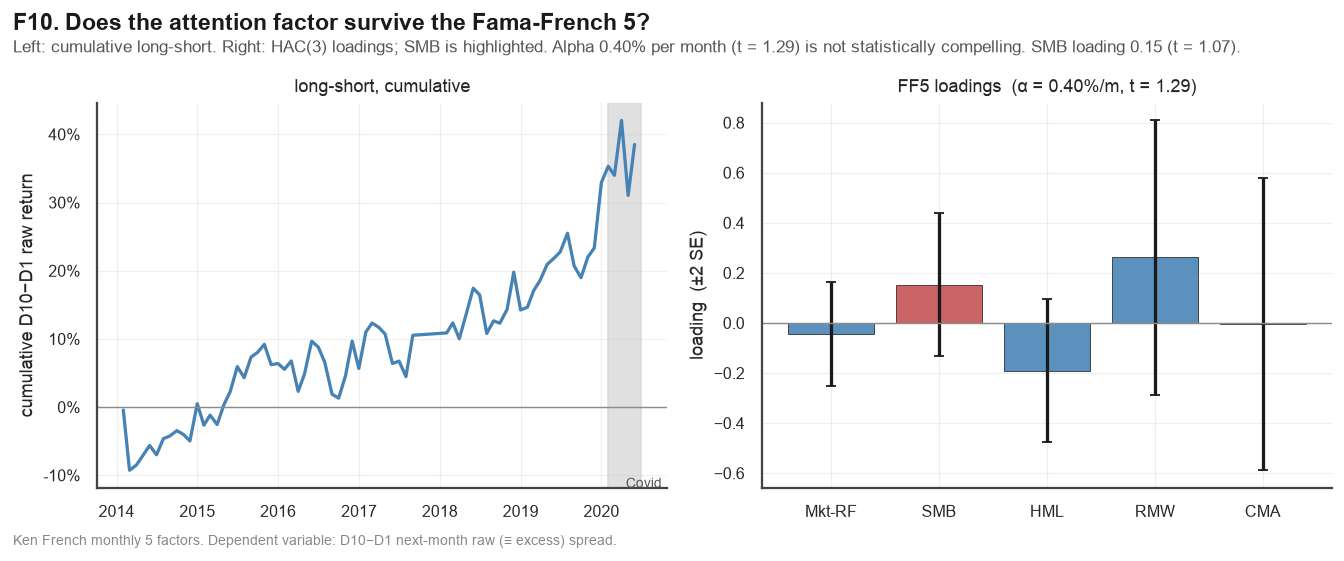

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2))
ax = axes[0]
_cum = (1 + spread.sort_index()).cumprod() - 1
ax.plot(_cum.index.tz_localize(None) if _cum.index.tz is not None else _cum.index,
        _cum.values, color=PALETTE["primary"])
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-30"),
           color=PALETTE["shade"], alpha=0.8, zorder=0)
ax.text(pd.Timestamp("2020-03-15"), ax.get_ylim()[0] if ax.get_ylim()[0] else 0,
        "  Covid", fontsize=8, color="#555555")
ax.axhline(0, color=PALETTE["neutral"], linewidth=0.8)
ax.set_ylabel("cumulative D10−D1 raw return")
pct_axis(ax, decimals=0)
ax.set_title("long-short, cumulative", fontsize=10)

ax = axes[1]
_load = ff_model.params.drop("const")
_se = ff_model.bse.drop("const")
_col = [PALETTE["accent"] if n == "SMB" else PALETTE["primary"] for n in _load.index]
ax.bar(_load.index, _load.values, yerr=2 * _se.values, color=_col,
       edgecolor="black", linewidth=0.4, capsize=3, alpha=0.88)
ax.axhline(0, color=PALETTE["neutral"], linewidth=0.8)
ax.set_ylabel("loading  (±2 SE)")
ax.set_title(f"FF5 loadings  (α = {alpha:.2%}/m, t = {alpha_t:.2f})", fontsize=10)

label_figure(
    fig,
    "F10. Does the attention factor survive the Fama-French 5?",
    f"Left: cumulative long-short. Right: HAC(3) loadings; SMB is highlighted. "
    f"Alpha {alpha:.2%} per month (t = {alpha_t:.2f}) is not statistically compelling. "
    f"SMB loading {smb:.2f} (t = {smb_t:.2f}).",
    "Ken French monthly 5 factors. Dependent variable: D10−D1 next-month raw (≡ excess) spread.",
)
plt.show()


The alpha is about +0.40% per month, t ≈ 1.29. That is not statistically compelling. SMB loads at about 0.15 (t ≈ 1.07), so this is not simply a size portfolio. The sort on residual returns is about +0.21% per month (t ≈ 0.69).


---

## Conclusion

After dropping duplicates, 6.48 million rows become 5.56 million messages. Nine of the 25 files mix two unrelated tickers, so tickers come from the cashtag. Attention is concentrated in a few of the scraped names and in a small set of accounts, many of them bots.

There are no sentiment labels in the files. On the SemEval benchmark we would use Twitter-RoBERTa. On our own messages the two transformers disagree often enough that we do not build the factor out of sentiment.

The factor is built only on the scraped focal equities (not the full S&P via co-mentions), sorted on abnormal unique-user attention into ten portfolios.

High-attention stocks earn about +0.50% more than low-attention stocks over the next month (HAC(3) t ≈ 1.76). The t-statistic is smaller with fewer lags. A shorter baseline, a different user floor and message counts all weaken the spread, and the weekly quintiles are about zero. The Fama-French alpha is about +0.40% per month with t ≈ 1.29.

We would not call this a robust new factor. The sign is positive and the main t-statistic is in a suggestive range, but the result moves when the measurement changes, the alpha is not compelling, and the panel is only about twenty scraped names with a four-month hole in 2017.


In [ ]:
print("Headline numbers this conclusion is referring to")
print("-" * 60)
print(f"  D10−D1 mean monthly raw spread : {spread.mean():+.4%}")
print(f"  HAC(3) t                       : {spread_hac_t:+.2f}")
print(f"  months                         : {int(len(spread))}")
print(f"  Sharpe (annualised)            : {annualised_sharpe(spread):.2f}")
if len(spread_abn):
    print(f"  D10−D1 of FF5 residuals        : {spread_abn.mean():+.4%}")
print(f"  FF5 alpha                      : {alpha:+.4%}  (t = {alpha_t:+.2f})")
print(f"  SMB loading                    : {smb:+.3f}  (t = {smb_t:+.2f})")
print(f"  F7 Spearman(raw vs g^ATT deciles): {rho_rank:+.2f}")
print(f"  primary sentiment model        : {PRIMARY_MODEL}")

_abs_spread = (f"{spread.mean()*100:+.2f} percent per month "
               f"(HAC(3) t = {spread_hac_t:.2f})")
_abs_frame = (f"is sorted within the scraped focal equities only "
              f"(Spearman of raw vs g^ATT deciles {rho_rank:+.2f})")
_abs_alpha = (f"The Fama-French alpha is {alpha*100:+.2f} percent per month "
              f"(t = {alpha_t:.2f}), which is not statistically compelling")
_abs_smb = f"SMB loading is {smb:.2f} (t = {smb_t:.2f})"

abstract = (
    f"We build a monthly attention factor from 5.56 million Stocktwits messages (2009-2020). "
    f"The symbol column is not a usable ticker, and collection drops out for four months in 2017. "
    f"The signal is abnormal unique-user attention over the previous 30 days, sorted into ten "
    f"equal-weighted portfolios of the scraped focal equities, held to the next formation close. Abnormal attention "
    f"{_abs_frame}. The D10-D1 next-month spread is {_abs_spread}. It weakens with a six-month "
    f"baseline, a different user floor, and message counts instead of users. {_abs_alpha}. "
    f"The {_abs_smb}. The files have no sentiment labels; on an external financial-microblog "
    f"benchmark the primary model is {PRIMARY_MODEL}."
)
print(abstract)


Headline numbers this conclusion is referring to
------------------------------------------------------------
  D10−D1 mean monthly raw spread : +0.4958%
  HAC(3) t                       : +1.76
  months                         : 73
  Sharpe (annualised)            : 0.55
  D10−D1 of FF5 residuals        : +0.2071%
  FF5 alpha                      : +0.3967%  (t = +1.29)
  SMB loading                    : +0.153  (t = +1.07)
  F7 Spearman, level vs abnormal : +0.97 vs +0.93
  primary sentiment model        : roberta
We build a monthly attention factor from 5.56 million Stocktwits messages (2009-2020). The symbol column is not a usable ticker, and collection drops out for four months in 2017. The signal is abnormal unique-user attention over the previous 30 days, sorted into ten equal-weighted S&P 500 portfolios held to the next formation close. Abnormal attention cuts the share of scraped names in the top decile from 83% to 24%. The deciles stay ordered (Spearman +0.97 to +0.93). The D

893

---

## Appendix — Time spent

| Block | Hours (approximate) | Who |
| --- | --- | --- |
| Assignment, lecture, Lab #2, both data folders | 6 | all three |
| Signal, blackout, coverage, sentiment sample | 8 | all three |
| Loading, cleaning, sentiment, portfolios, figures | 14 | coding, then the group |
| Write-up | 4 | all three |
| **Total** | **~32** | |
